In [3]:
print("работает")

работает


In [4]:
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path("..") / "data" / "raw"
RAW.mkdir(parents=True, exist_ok=True)
print("Папка для данных:", RAW.resolve())

Папка для данных: C:\analytics\brain-25-evidence\data\raw


In [5]:
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path("..") / "data" / "raw"
RAW.mkdir(parents=True, exist_ok=True)
print("Папка для данных:", RAW.resolve())

Папка для данных: C:\analytics\brain-25-evidence\data\raw


In [6]:
import sys
print("Ядро использует:", sys.executable)
!{sys.executable} -m pip install requests

Ядро использует: c:\Users\TshK\AppData\Local\Python\pythoncore-3.14-64\python.exe


import matplotlib
print("pandas:", pd.__version__)
print("requests:", requests.__version__)
print("matplotlib:", matplotlib.__version__)
print("✅ все библиотеки на месте")

In [7]:
import time
import requests
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

In [8]:
import matplotlib
print("pandas:", pd.__version__)
print("requests:", requests.__version__)
print("matplotlib:", matplotlib.__version__)
print("✅ все библиотеки на месте")

pandas: 3.0.5
requests: 2.34.2
matplotlib: 3.11.1
✅ все библиотеки на месте


In [9]:
RAW = Path("..") / "data" / "raw"
RAW.mkdir(parents=True, exist_ok=True)
print("Папка для данных:", RAW.resolve())

Папка для данных: C:\analytics\brain-25-evidence\data\raw


In [10]:
COG = '(cognition OR cognitive OR memory OR attention OR "executive function")'

SUPPLEMENTS = {
    "Креатин": f"creatine AND {COG}",
    "Омега-3": f'("omega-3 fatty acids" OR "fish oil" OR "docosahexaenoic acid" OR "eicosapentaenoic acid") AND {COG}',
    "Витамин D": f'("vitamin D" OR cholecalciferol OR calcidiol) AND {COG}',
    "B12": f'("vitamin B12" OR cobalamin) AND {COG}',
    "Магний": f"magnesium AND {COG}",
    "Кофеин": f"caffeine AND {COG}",
    "L-Теанин": f"theanine AND {COG}",
    "Бакопа": f'("bacopa monnieri" OR bacopa) AND {COG}',
    "Ежовик": f'("hericium erinaceus" OR "lions mane") AND {COG}',
    "Гинкго": f'("ginkgo biloba" OR ginkgo) AND {COG}',
    "Родиола": f'("rhodiola rosea" OR rhodiola) AND {COG}',
    "Ашваганда": f'(ashwagandha OR "withania somnifera") AND {COG}',
    "Фосфатидилсерин": f"phosphatidylserine AND {COG}",
    "Alpha-GPC": f'("alpha-gpc" OR alfoscerate) AND {COG}',
    "CDP-холин": f'(citicoline OR "cdp-choline") AND {COG}',
    "Гуперзин А": f"huperzine AND {COG}",
    "Куркумин": f"(curcumin OR curcuma OR turmeric) AND {COG}",
    "Ресвератрол": f"resveratrol AND {COG}",
    "NAC": f'("n-acetylcysteine" OR acetylcysteine) AND {COG}',
    "Цинк": f"zinc AND {COG}",
    "Тирозин": f"tyrosine AND {COG}",
    "Таурин": f"taurine AND {COG}",
    "CoQ10": f'("coenzyme q10" OR ubiquinone) AND {COG}',
    "Пикногенол": f'(pycnogenol OR "pinus pinaster") AND {COG}',
    "Готу кола": f'("centella asiatica" OR "gotu kola") AND {COG}',
}
print(f"Добавок в анализе: {len(SUPPLEMENTS)}")

Добавок в анализе: 25


In [11]:
URL = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"

def count(query: str) -> int:
    try:
        r = requests.get(URL, params={"db": "pubmed", "term": query,
                                      "retmax": 0, "retmode": "json"}, timeout=15)
        r.raise_for_status()
        time.sleep(0.35)
        return int(r.json()["esearchresult"]["count"])
    except Exception as e:
        print(f"⚠️ Ошибка запроса: {e}")
        return -1

In [12]:
rows = []
for name, term in SUPPLEMENTS.items():
    total = count(term)
    rct   = count(f"{term} AND randomized controlled trial[pt]")
    meta  = count(f"{term} AND meta-analysis[pt]")
    rows.append([name, total, rct, meta])
    print(f"{name}: всего={total} | RCT={rct} | мета={meta}")

df = pd.DataFrame(rows, columns=["добавка", "всего_публикаций", "rct", "мета_анализы"])
df = df.sort_values("rct", ascending=False).reset_index(drop=True)
df.to_csv(RAW / "pubmed_evidence.csv", index=False, encoding="utf-8-sig")
df

Креатин: всего=2312 | RCT=116 | мета=25
Омега-3: всего=2366 | RCT=295 | мета=52
Витамин D: всего=4071 | RCT=175 | мета=86


KeyboardInterrupt: 

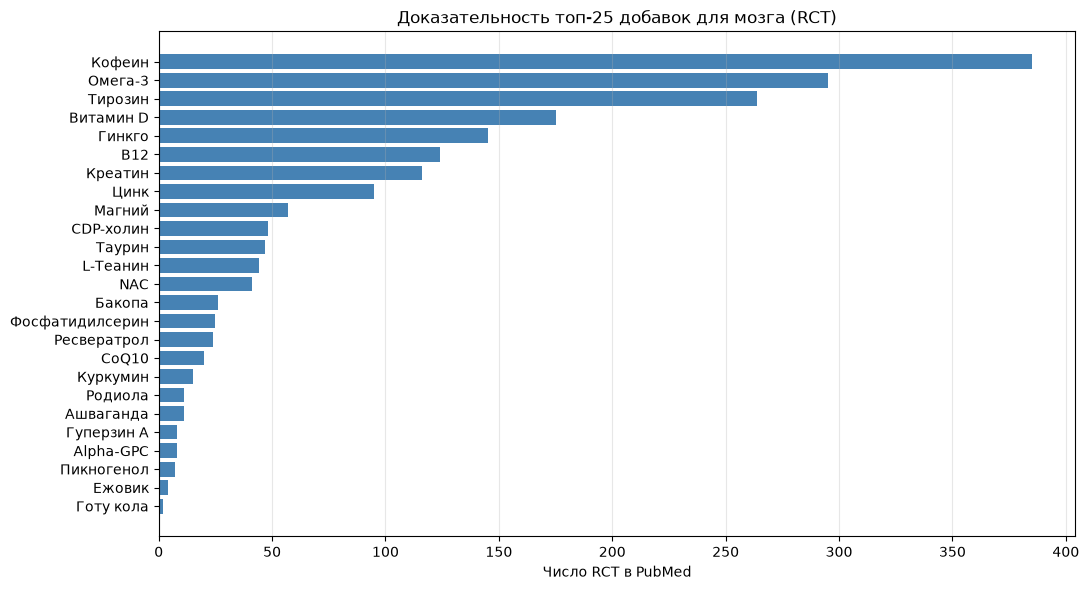

In [ ]:
plt.figure(figsize=(11, 6))
plt.barh(df["добавка"], df["rct"], color="steelblue")
plt.xlabel("Число RCT в PubMed")
plt.title("Доказательность топ-25 добавок для мозга (RCT)")
plt.gca().invert_yaxis()
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
plt.savefig("../reports/rct_chart.png", dpi=150, bbox_inches="tight")
print("График сохранён в reports/rct_chart.png")

График сохранён в reports/rct_chart.png


<Figure size 640x480 with 0 Axes>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path("..") / "data" / "raw"
df = pd.read_csv(RAW / "pubmed_evidence.csv")
print(df.shape)
df.head()

(25, 4)


,добавка,всего_публикаций,rct,мета_анализы
0,Кофеин,2692,385,39
1,Омега-3,2366,295,52
2,Тирозин,9979,264,39
3,Витамин D,4071,175,86
4,Гинкго,1144,145,47


In [ ]:
df["score"] = df["rct"] + 5 * df["мета_анализы"]
df = df.sort_values("score", ascending=False).reset_index(drop=True)
df

,добавка,всего_публикаций,rct,мета_анализы,score
0,Витамин D,4071,175,86,605
1,Кофеин,2692,385,39,580
2,Омега-3,2366,295,52,555
3,Тирозин,9979,264,39,459
4,Гинкго,1144,145,47,380
5,B12,2089,124,50,374
6,Цинк,6559,95,45,320
7,Креатин,2312,116,25,241
8,Магний,2704,57,23,172
9,NAC,729,41,14,111


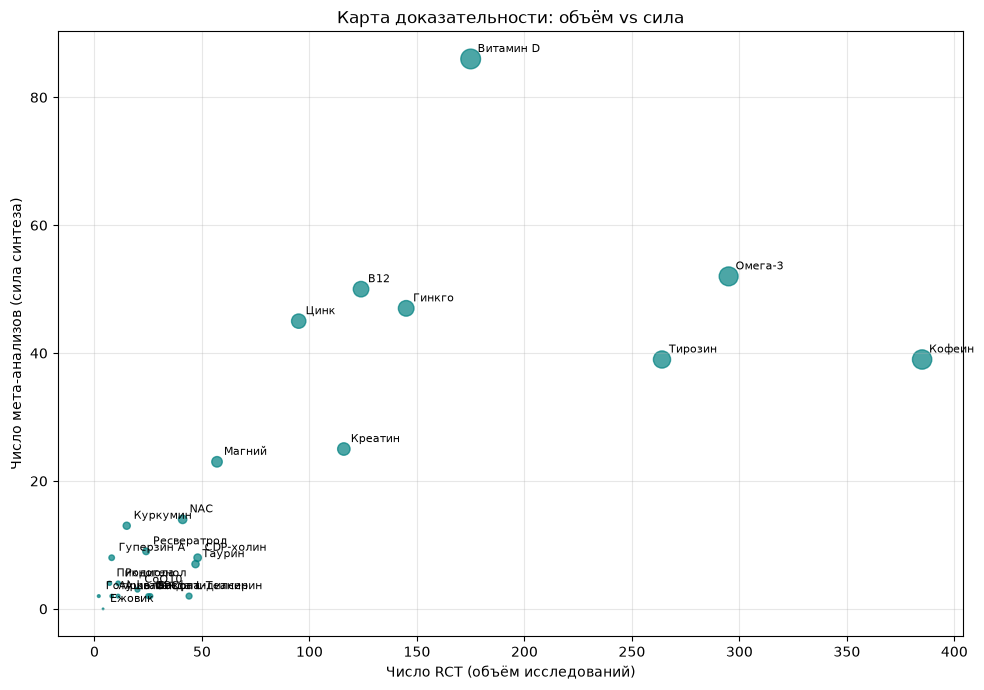

In [13]:
plt.figure(figsize=(10, 7))
plt.scatter(df["rct"], df["мета_анализы"], s=df["score"]/3, alpha=0.7, color="teal")
for _, row in df.iterrows():
    plt.annotate(row["добавка"], (row["rct"], row["мета_анализы"]),
                 fontsize=8, xytext=(5, 5), textcoords="offset points")
plt.xlabel("Число RCT (объём исследований)")
plt.ylabel("Число мета-анализов (сила синтеза)")
plt.title("Карта доказательности: объём vs сила")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path("..") / "data" / "raw"
df = pd.read_csv(RAW / "pubmed_evidence.csv")
print(df.shape)

(25, 4)


In [ ]:
df["score"] = df["rct"] + 5 * df["мета_анализы"]
df = df.sort_values("score", ascending=False).reset_index(drop=True)
print(df.shape)

(25, 5)


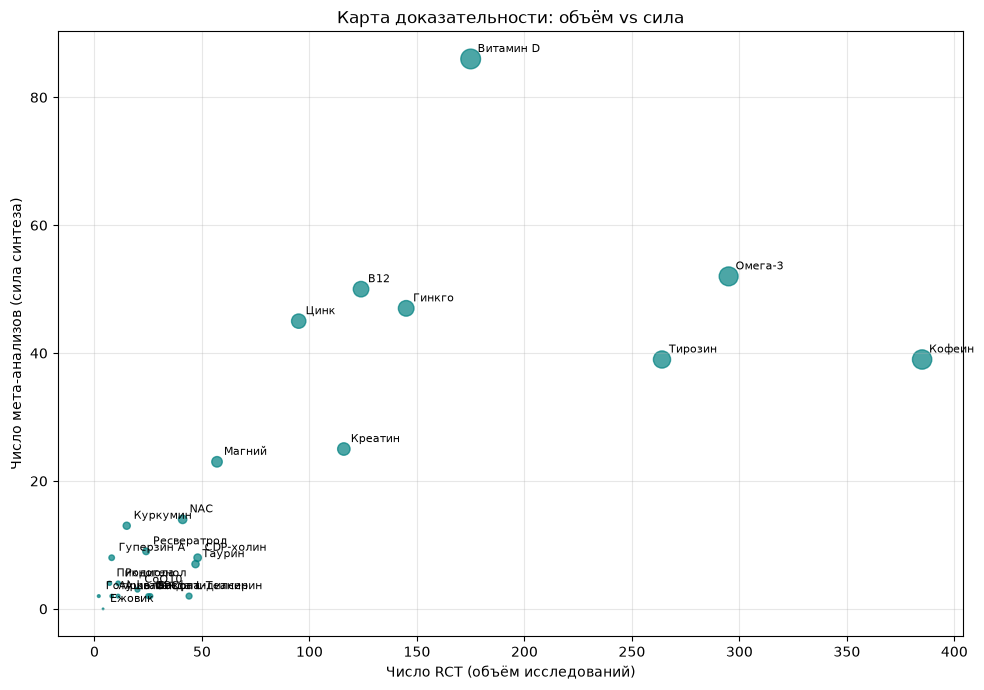

In [14]:
plt.figure(figsize=(10, 7))
plt.scatter(df["rct"], df["мета_анализы"], s=df["score"]/3, alpha=0.7, color="teal")
for _, row in df.iterrows():
    plt.annotate(row["добавка"], (row["rct"], row["мета_анализы"]),
                 fontsize=8, xytext=(5, 5), textcoords="offset points")
plt.xlabel("Число RCT (объём исследований)")
plt.ylabel("Число мета-анализов (сила синтеза)")
plt.title("Карта доказательности: объём vs сила")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
MY_TIER = {
    "Креатин": 1, "Омега-3": 1, "Кофеин": 1, "L-Теанин": 1, "Бакопа": 1,
    "Ашваганда": 1, "Витамин D": 1, "B12": 1, "Цинк": 1,
    "Магний": 2, "Родиола": 2, "Ежовик": 2, "CDP-холин": 2, "Alpha-GPC": 2,
    "Фосфатидилсерин": 2, "Гуперзин А": 2, "NAC": 2, "Тирозин": 2,
    "Гинкго": 3, "Куркумин": 3, "Ресвератрол": 3, "Таурин": 3, "CoQ10": 3,
    "Пикногенол": 3, "Готу кола": 3,
}
df["мой_ярус"] = df["добавка"].map(MY_TIER)
df["ярус_по_данным"] = pd.qcut(df["score"], q=3, labels=[3, 2, 1]).astype(int)
df["расхождение"] = df["мой_ярус"] - df["ярус_по_данным"]

cmp = df[["добавка", "score", "мой_ярус", "ярус_по_данным", "расхождение"]]
cmp.reindex(cmp["расхождение"].abs().sort_values(ascending=False).index)

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
RAW = Path("..") / "data" / "raw"
df = pd.read_csv(RAW / "pubmed_evidence.csv")
df["score"] = df["rct"] + 5 * df["мета_анализы"]
df = df.sort_values("score", ascending=False).reset_index(drop=True)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
RAW = Path("..") / "data" / "raw"
df = pd.read_csv(RAW / "pubmed_evidence.csv")
df["score"] = df["rct"] + 5 * df["мета_анализы"]
df = df.sort_values("score", ascending=False).reset_index(drop=True)

In [3]:
MY_TIER = {
    "Креатин": 1, "Омега-3": 1, "Кофеин": 1, "L-Теанин": 1, "Бакопа": 1,
    "Ашваганда": 1, "Витамин D": 1, "B12": 1, "Цинк": 1,
    "Магний": 2, "Родиола": 2, "Ежовик": 2, "CDP-холин": 2, "Alpha-GPC": 2,
    "Фосфатидилсерин": 2, "Гуперзин А": 2, "NAC": 2, "Тирозин": 2,
    "Гинкго": 3, "Куркумин": 3, "Ресвератрол": 3, "Таурин": 3, "CoQ10": 3,
    "Пикногенол": 3, "Готу кола": 3,
}
df["мой_ярус"] = df["добавка"].map(MY_TIER)
df["ярус_по_данным"] = pd.qcut(df["score"], q=3, labels=[3, 2, 1]).astype(int)
df["расхождение"] = df["мой_ярус"] - df["ярус_по_данным"]

cmp = df[["добавка", "score", "мой_ярус", "ярус_по_данным", "расхождение"]]
cmp.reindex(cmp["расхождение"].abs().sort_values(ascending=False).index)

,добавка,score,мой_ярус,ярус_по_данным,расхождение
4,Гинкго,380,3,1,2
21,Ашваганда,21,1,3,-2
16,Бакопа,36,1,3,-2
3,Тирозин,459,2,1,1
18,Фосфатидилсерин,35,2,3,-1
12,Куркумин,80,3,2,1
13,Ресвератрол,69,3,2,1
22,Alpha-GPC,18,2,3,-1
14,L-Теанин,54,1,2,-1
24,Ежовик,4,2,3,-1


In [ ]:
PROCESSED = Path("..") / "data" / "processed"
df.to_csv(PROCESSED / "evidence_scored.csv", index=False, encoding="utf-8-sig")
plt.savefig("../reports/evidence_scatter.png", dpi=150, bbox_inches="tight")
print("Сохранено: evidence_scored.csv + evidence_scatter.png")

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path("..") / "data" / "raw"
df = pd.read_csv(RAW / "pubmed_evidence.csv")
df["score"] = df["rct"] + 5 * df["мета_анализы"]
df = df.sort_values("score", ascending=False).reset_index(drop=True)
print(df.shape)

(25, 5)


In [2]:
PROCESSED = Path("..") / "data" / "processed"
df.to_csv(PROCESSED / "evidence_scored.csv", index=False, encoding="utf-8-sig")
print("CSV сохранён:", (PROCESSED / "evidence_scored.csv").resolve())

CSV сохранён: C:\analytics\brain-25-evidence\data\processed\evidence_scored.csv


In [4]:
EN = {"Креатин":"creatine","Омега-3":"omega-3 fatty acids","Витамин D":"vitamin D",
"B12":"vitamin B12","Магний":"magnesium","Кофеин":"caffeine","L-Теанин":"theanine",
"Бакопа":"bacopa monnieri","Ежовик":"hericium erinaceus","Гинкго":"ginkgo biloba",
"Родиола":"rhodiola rosea","Ашваганда":"ashwagandha","Фосфатидилсерин":"phosphatidylserine",
"Alpha-GPC":"alpha-gpc","CDP-холин":"citicoline","Гуперзин А":"huperzine",
"Куркумин":"curcumin","Ресвератрол":"resveratrol","NAC":"n-acetylcysteine",
"Цинк":"zinc","Тирозин":"tyrosine","Таурин":"taurine","CoQ10":"coenzyme q10",
"Пикногенол":"pycnogenol","Готу кола":"centella asiatica"}
df["name_en"] = df["добавка"].map(EN)
print("Пропусков в переводе:", df["name_en"].isna().sum())

Пропусков в переводе: 0


In [ ]:
import requests
import time

def openalex_count(query: str) -> int:
    try:
        r = requests.get("https://api.openalex.org/works",
                         params={"search": query, "per-page": 1,
                                 "mailto": "deadsno1613@gmail.com"},
                         timeout=15)
        r.raise_for_status()
        time.sleep(0.35)
        return int(r.json()["meta"]["count"])
    except Exception as e:
        print("⚠️", e)
        return -1

df["openalex_works"] = [openalex_count(f"{en} cognition") for en in df["name_en"]]
df[["добавка", "всего_публикаций", "openalex_works"]]

⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined
⚠️ name 'requests' is not defined


,добавка,всего_публикаций,openalex_works
0,Витамин D,4071,-1
1,Кофеин,2692,-1
2,Омега-3,2366,-1
3,Тирозин,9979,-1
4,Гинкго,1144,-1
5,B12,2089,-1
6,Цинк,6559,-1
7,Креатин,2312,-1
8,Магний,2704,-1
9,NAC,729,-1


In [ ]:
import requests
import time

In [ ]:
import requests, time
t0 = time.time()
try:
    r = requests.get("https://api.openalex.org/works",
                     params={"search": "creatine cognition", "per-page": 1},
                     timeout=10)
    print("Статус:", r.status_code, "| работ:", r.json()["meta"]["count"],
          f"| время: {time.time()-t0:.1f} сек")
except Exception as e:
    print("ОШИБКА:", type(e).__name__, e, f"| время: {time.time()-t0:.1f} сек")

In [1]:
import requests, time
t0 = time.time()
try:
    r = requests.get("https://api.openalex.org/works",
                     params={"search": "creatine cognition", "per-page": 1},
                     timeout=10)
    print("Статус:", r.status_code, "| работ:", r.json()["meta"]["count"],
          f"| время: {time.time()-t0:.1f} сек")
except Exception as e:
    print("ОШИБКА:", type(e).__name__, e, f"| время: {time.time()-t0:.1f} сек")

Статус: 200 | работ: 10635 | время: 1.3 сек


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

RAW = Path("..") / "data" / "raw"
df = pd.read_csv(RAW / "pubmed_evidence.csv")
df["score"] = df["rct"] + 5 * df["мета_анализы"]
df = df.sort_values("score", ascending=False).reset_index(drop=True)
print(df.shape)

(25, 5)


In [3]:
EN = {"Креатин":"creatine","Омега-3":"omega-3 fatty acids","Витамин D":"vitamin D",
"B12":"vitamin B12","Магний":"magnesium","Кофеин":"caffeine","L-Теанин":"theanine",
"Бакопа":"bacopa monnieri","Ежовик":"hericium erinaceus","Гинкго":"ginkgo biloba",
"Родиола":"rhodiola rosea","Ашваганда":"ashwagandha","Фосфатидилсерин":"phosphatidylserine",
"Alpha-GPC":"alpha-gpc","CDP-холин":"citicoline","Гуперзин А":"huperzine",
"Куркумин":"curcumin","Ресвератрол":"resveratrol","NAC":"n-acetylcysteine",
"Цинк":"zinc","Тирозин":"tyrosine","Таурин":"taurine","CoQ10":"coenzyme q10",
"Пикногенол":"pycnogenol","Готу кола":"centella asiatica"}
df["name_en"] = df["добавка"].map(EN)
print("Пропусков в переводе:", df["name_en"].isna().sum())

Пропусков в переводе: 0


In [4]:
import requests, time

def openalex_count(query):
    try:
        r = requests.get("https://api.openalex.org/works",
                         params={"search": query, "per-page": 1,
                                 "mailto": "deadsno1613@gmail.com"},
                         timeout=8)
        r.raise_for_status()
        time.sleep(0.35)
        return int(r.json()["meta"]["count"])
    except Exception as e:
        print("⚠️", query, type(e).__name__)
        return -1

for i, en in enumerate(df["name_en"]):
    df.loc[i, "openalex_works"] = openalex_count(f"{en} cognition")
    print(f"{i+1}/25 {en} → {int(df.loc[i, 'openalex_works'])}")

1/25 vitamin D → 64004
2/25 caffeine → 25556
3/25 omega-3 fatty acids → 16636
4/25 tyrosine → 36062
5/25 ginkgo biloba → 4479
6/25 vitamin B12 → 12070
7/25 zinc → 26038
8/25 creatine → 10635
9/25 magnesium → 14539
10/25 n-acetylcysteine → 4267
11/25 citicoline → 814
12/25 taurine → 4942
13/25 curcumin → 10073
14/25 resveratrol → 10010
15/25 theanine → 1217
16/25 huperzine → 1249
17/25 bacopa monnieri → 1332
18/25 coenzyme q10 → 2990
19/25 phosphatidylserine → 2930
20/25 rhodiola rosea → 644
21/25 pycnogenol → 301
22/25 ashwagandha → 1267
23/25 alpha-gpc → 686
24/25 centella asiatica → 1424
25/25 hericium erinaceus → 383


In [5]:
df["rct_share"] = (df["rct"] / df["всего_публикаций"] * 100).round(1)
df.sort_values("rct_share", ascending=False)[["добавка", "всего_публикаций", "rct", "rct_share"]]

,добавка,всего_публикаций,rct,rct_share
14,L-Теанин,218,44,20.2
10,CDP-холин,320,48,15.0
1,Кофеин,2692,385,14.3
22,Alpha-GPC,61,8,13.1
4,Гинкго,1144,145,12.7
2,Омега-3,2366,295,12.5
20,Пикногенол,75,7,9.3
19,Родиола,137,11,8.0
16,Бакопа,341,26,7.6
11,Таурин,750,47,6.3


In [6]:
print("Корреляция PubMed vs OpenAlex:",
      round(df["всего_публикаций"].corr(df["openalex_works"]), 2))

Корреляция PubMed vs OpenAlex: 0.75


In [7]:
PROCESSED = Path("..") / "data" / "processed"
df.to_csv(PROCESSED / "evidence_scored.csv", index=False, encoding="utf-8-sig")
print("Сохранено:", (PROCESSED / "evidence_scored.csv").resolve())

Сохранено: C:\analytics\brain-25-evidence\data\processed\evidence_scored.csv


In [8]:
# +1 = мета-анализы говорят «эффект есть»
#  0 = смешанно / зависит от контекста
# -1 = мета-анализы говорят «эффекта нет» или данных мало

VERDICT = {
    "Креатин":              1,   # при недосыпе/вегетарианцы — доказан
    "Омега-3":              1,   # умеренный, но стабильный эффект
    "Кофеин":               1,   # внимание/бдительность — твёрдо
    "L-Теанин":             1,   # в связке с кофеином — спокойный фокус
    "Бакопа":               1,   # память, по мета-анализам
    "Ашваганда":            1,   # стресс/сон — крепкие RCT
    "Витамин D":            0,   # только при дефиците
    "B12":                  0,   # только при дефиците
    "Цинк":                 0,   # при дефиците
    "Магний":               0,   # сон/стресс, при дефиците
    "Родиола":              0,   # утомляемость, малые RCT
    "CDP-холин":            0,   # умеренно, у пожилых
    "Alpha-GPC":            0,   # мало человеческих RCT
    "Фосфатидилсерин":      0,   # пожилые, малые RCT
    "Гуперзин А":           0,   # в основном Китай/деменция
    "NAC":                  0,   # больше психиатрия
    "Тирозин":              0,   # только при стрессе/недосыпе
    "Таурин":              -1,   # почти нет RCT по когнитивке
    "Ежовик":              -1,   # обещает, но доказательств мало
    "Пикногенол":          -1,   # малые исследования
    "Готу кола":           -1,   # единицы RCT
    "Куркумин":            -1,   # биодоступность = проблема
    "Ресвератрол":         -1,   # in vitro звезда, in vivo слабо
    "CoQ10":               -1,   # для когнитивки слабо
    "Гинкго":              -1,   # много RCT, но выводы «эффекта нет»
}

df["вердикт"] = df["добавка"].map(VERDICT)
print("Разметка готова:", df["вердикт"].value_counts().to_dict())

df[["добавка", "score", "rct_share", "вердикт"]]\
  .sort_values(["вердикт", "score"], ascending=[False, False])

Разметка готова: {0: 11, -1: 8, 1: 6}


,добавка,score,rct_share,вердикт
1,Кофеин,580,14.3,1
2,Омега-3,555,12.5,1
7,Креатин,241,5.0,1
14,L-Теанин,54,20.2,1
16,Бакопа,36,7.6,1
21,Ашваганда,21,4.3,1
0,Витамин D,605,4.3,0
3,Тирозин,459,2.6,0
5,B12,374,5.9,0
6,Цинк,320,1.4,0


In [ ]:
# Норма на месяц: сколько единиц (капсул или грамм) уходит за 30 дней
NORM = {
    "Креатин": 150,   # грамм порошка (5 г/день × 30)
    "Тирозин": 15,    # грамм (500 мг × 30)
    "Таурин": 30,     # грамм (1 г × 30)
}
for name in df["добавка"]:
    NORM.setdefault(name, 30)   # остальные: 30 капсул = 1 капс = суточная доза

rows = []
for name in df["добавка"]:
    for i in range(5):
        rows.append({
            "добавка": name,
            "продукт": "",
            "единиц_в_упаковке": "",  # капсул ИЛИ грамм в упаковке
            "цена_упаковки": "",      # ₽
            "норма_мес": NORM[name],  # единиц в месяц (правишь, если доза другая)
            "источник": "",
            "дата": "",
        })
tmpl = pd.DataFrame(rows)
tmpl.to_csv(RAW / "prices_raw.csv", index=False, encoding="utf-8-sig")
print(f"Шаблон создан: {len(tmpl)} строк → data/raw/prices_raw.csv")

In [2]:
import pandas as pd
from pathlib import Path

RAW = Path("..") / "data"

In [4]:
import pandas as pd
from pathlib import Path

RAW = Path("..") / "data" / "raw"

NORM = {"Креатин":150,"Омега-3":60,"Витамин D":30,"B12":30,"Магний":30,
"Кофеин":30,"L-Теанин":30,"Бакопа":30,"Ежовик":60,"Гинкго":30,"Родиола":30,
"Ашваганда":30,"Фосфатидилсерин":30,"Alpha-GPC":30,"CDP-холин":30,
"Гуперзин А":30,"Куркумин":60,"Ресвератрол":30,"NAC":60,"Цинк":30,
"Тирозин":60,"Таурин":60,"CoQ10":30,"Пикногенол":30,"Готу кола":30}

rows = [{"добавка": n, "продукт": "", "единиц_в_упаковке": "",
         "цена_упаковки": "", "норма_мес": NORM[n], "источник": "", "дата": ""}
        for n in NORM for _ in range(5)]
pd.DataFrame(rows).to_excel(RAW / "prices_raw.xlsx", index=False)
print("Чистый шаблон: data/raw/prices_raw.xlsx | строк:", len(rows))

Чистый шаблон: data/raw/prices_raw.xlsx | строк: 125


In [3]:
import requests
import pandas as pd

def wb_search(query: str, n: int = 10):
    url = "https://search.wb.ru/exactmatch/ru/common/v4/search"
    params = {"appType": 1, "curr": "rub", "dest": -1257786,
              "query": query, "resultset": "catalog",
              "sort": "popular", "spp": 30}
    r = requests.get(url, params=params, timeout=15,
                     headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    items = r.json()["data"]["products"][:n]
    return pd.DataFrame([{
        "артикул": it["id"],
        "бренд": it.get("brand", ""),
        "название": it.get("name", ""),
        "цена_руб": round(it.get("salePriceU", it.get("priceU", 0)) / 100),
    } for it in items])

test = wb_search("креатин моногидрат")
test

KeyError: 'data'

In [2]:
import requests, time
t0 = time.time()
try:
    r = requests.get("https://search.wb.ru/exactmatch/ru/common/v4/search",
                     params={"appType": 1, "curr": "rub", "dest": -1257786,
                             "query": "креатин", "resultset": "catalog"},
                     timeout=10, headers={"User-Agent": "Mozilla/5.0"})
    print("Статус:", r.status_code, f"| время: {time.time()-t0:.1f} сек")
except Exception as e:
    print("ОШИБКА:", type(e).__name__, e, f"| время: {time.time()-t0:.1f} сек")

Статус: 200 | время: 0.1 сек


In [1]:
import requests

r = requests.get("https://search.wb.ru/exactmatch/ru/common/v4/search",
                 params={"appType": 1, "curr": "rub", "dest": -1257786,
                         "query": "креатин моногидрат", "resultset": "catalog"},
                 timeout=15, headers={"User-Agent": "Mozilla/5.0"})
print("Статус:", r.status_code)
print("\nКлючи верхнего уровня:")
print(list(r.json().keys()))

Статус: 200

Ключи верхнего уровня:
['metadata', 'products', 'total']


In [ ]:
def wb_search(query: str, n: int = 10):
    url = "https://search.wb.ru/exactmatch/ru/common/v4/search"
    params = {"appType": 1, "curr": "rub", "dest": -1257786,
              "query": query, "resultset": "catalog",
              "sort": "popular", "spp": 30}
    r = requests.get(url, params=params, timeout=15,
                     headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    data = r.json()
    # пробуем два варианта структуры
    items = data.get("products", data.get("data", {}).get("products", []))[:n]
    return pd.DataFrame([{
        "артикул": it.get("id"),
        "бренд": it.get("brand", ""),
        "название": it.get("name", ""),
        "цена_руб": round(it.get("salePriceU", it.get("priceU", 0)) / 100),
    } for it in items])

test = wb_search("креатин моногидрат")
test

NameError: name 'pd' is not defined

In [3]:
import requests
import pandas as pd

def wb_search(query: str, n: int = 10):
    url = "https://search.wb.ru/exactmatch/ru/common/v4/search"
    params = {"appType": 1, "curr": "rub", "dest": -1257786,
              "query": query, "resultset": "catalog",
              "sort": "popular", "spp": 30}
    r = requests.get(url, params=params, timeout=15,
                     headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    data = r.json()
    items = data.get("products", data.get("data", {}).get("products", []))[:n]
    return pd.DataFrame([{
        "артикул": it.get("id"),
        "бренд": it.get("brand", ""),
        "название": it.get("name", ""),
        "цена_руб": round(it.get("salePriceU", it.get("priceU", 0)) / 100),
    } for it in items])

test = wb_search("креатин моногидрат")
test

,артикул,бренд,название,цена_руб
0,4219394,Prime Kraft,"Креатин моногидрат Creatine Monohydrate, без в...",0
1,13257465,Prime Kraft,Креатин Creatine Monohydrate 100% Pure (без вк...,0
2,120930475,Prime Kraft,"Креатин Creatine Monohydrate, Вишня 200 гр",0
3,228766204,Prime Kraft,"Креатин Creatine Monohydrate, Энергетик 200 гр",0
4,120930473,Prime Kraft,"Креатин Creatine Monohydrate, Ананас 200 гр",0
5,120930474,Prime Kraft,"Креатин Creatine Monohydrate, Цитрусовый микс ...",0
6,183766036,Prime Kraft,"Креатин Creatine Monohydrate, Вишня 500 гр",0
7,183766034,Prime Kraft,Креатин Creatine Monohydrate Pineapple (ананас...,0
8,7002141,BIGSNT,Креатин моногидрат порошок,0
9,59102656,BIOVIN,"Креатин моногидрат порошок, спортивное питание...",0


In [4]:
NORM = {"Креатин":150,"Омега-3":60,"Витамин D":30,"B12":30,"Магний":30,
"Кофеин":30,"L-Теанин":30,"Бакопа":30,"Ежовик":60,"Гинкго":30,"Родиола":30,
"Ашваганда":30,"Фосфатидилсерин":30,"Alpha-GPC":30,"CDP-холин":30,
"Гуперзин А":30,"Куркумин":60,"Ресвератрол":30,"NAC":60,"Цинк":30,
"Тирозин":60,"Таурин":60,"CoQ10":30,"Пикногенол":30,"Готу кола":30}
print("NORM жив:", len(NORM), "добавок")

NORM жив: 25 добавок


In [5]:
def wb_search(query: str, n: int = 10):
    url = "https://search.wb.ru/exactmatch/ru/common/v4/search"
    params = {"appType": 1, "curr": "rub", "dest": -1257786,
              "query": query, "resultset": "catalog",
              "sort": "popular", "spp": 30}
    r = requests.get(url, params=params, timeout=15,
                     headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    data = r.json()
    # пробуем два варианта структуры
    items = data.get("products", data.get("data", {}).get("products", []))[:n]
    return pd.DataFrame([{
        "артикул": it.get("id"),
        "бренд": it.get("brand", ""),
        "название": it.get("name", ""),
        "цена_руб": round(it.get("salePriceU", it.get("priceU", 0)) / 100),
    } for it in items])

test = wb_search("креатин моногидрат")
test

,артикул,бренд,название,цена_руб
0,4219394,Prime Kraft,"Креатин моногидрат Creatine Monohydrate, без в...",0
1,13257465,Prime Kraft,Креатин Creatine Monohydrate 100% Pure (без вк...,0
2,120930475,Prime Kraft,"Креатин Creatine Monohydrate, Вишня 200 гр",0
3,228766204,Prime Kraft,"Креатин Creatine Monohydrate, Энергетик 200 гр",0
4,120930473,Prime Kraft,"Креатин Creatine Monohydrate, Ананас 200 гр",0
5,120930474,Prime Kraft,"Креатин Creatine Monohydrate, Цитрусовый микс ...",0
6,183766036,Prime Kraft,"Креатин Creatine Monohydrate, Вишня 500 гр",0
7,183766034,Prime Kraft,Креатин Creatine Monohydrate Pineapple (ананас...,0
8,7002141,BIGSNT,Креатин моногидрат порошок,0
9,59102656,BIOVIN,"Креатин моногидрат порошок, спортивное питание...",0


In [6]:
import requests

r = requests.get("https://search.wb.ru/exactmatch/ru/common/v4/search",
                 params={"appType": 1, "curr": "rub", "dest": -1257786,
                         "query": "креатин моногидрат", "resultset": "catalog",
                         "sort": "popular", "spp": 30},
                 timeout=15, headers={"User-Agent": "Mozilla/5.0"})
data = r.json()
items = data.get("products", data.get("data", {}).get("products", []))

if items:
    first = items[0]
    print("Ключи первого товара:")
    print(list(first.keys()))
    print("\nВсе ключи, содержащие 'price' или 'Price':")
    for k in first:
        if "price" in k.lower():
            print(f"  {k}: {first[k]}")
    print("\nПолный первый товар (для отладки):")
    import json
    print(json.dumps(first, ensure_ascii=False, indent=2)[:2000])

Ключи первого товара:
['id', '__sort', 'ksort', 'root', 'kindId', 'brand', 'brandId', 'siteBrandId', 'colors', 'subjectId', 'subjectParentId', 'semanticId', 'name', 'entity', 'matchId', 'supplier', 'supplierId', 'supplierRating', 'supplierFlags', 'pics', 'picsUpdate', 'rating', 'reviewRating', 'feedbacks', 'panelPromoId', 'volume', 'weight', 'viewFlags', 'mtype', 'sizes', 'totalQuantity', 'time1', 'time2', 'wh', 'dtype', 'ndtype', 'dtypeMask', 'dist', 'meta']

Все ключи, содержащие 'price' или 'Price':

Полный первый товар (для отладки):
{
  "id": 4219394,
  "__sort": 606023,
  "ksort": 0,
  "root": 3472725,
  "kindId": 0,
  "brand": "Prime Kraft",
  "brandId": 14823,
  "siteBrandId": 0,
  "colors": [],
  "subjectId": 1110,
  "subjectParentId": 1081,
  "semanticId": [
    42,
    0,
    2,
    21,
    89,
    24,
    7
  ],
  "name": "Креатин моногидрат Creatine Monohydrate, без вкуса 200 гр",
  "entity": "",
  "matchId": 632459347,
  "supplier": "Prime Kraft",
  "supplierId": 17367,
 

In [7]:
import requests
import json

r = requests.get("https://search.wb.ru/exactmatch/ru/common/v4/search",
                 params={"appType": 1, "curr": "rub", "dest": -1257786,
                         "query": "креатин моногидрат", "resultset": "catalog",
                         "sort": "popular", "spp": 30},
                 timeout=15, headers={"User-Agent": "Mozilla/5.0"})
data = r.json()
items = data.get("products", data.get("data", {}).get("products", []))

if items and items[0].get("sizes"):
    first_size = items[0]["sizes"][0]
    print("Ключи внутри sizes[0]:")
    print(list(first_size.keys()))
    print("\nВсе ключи со словом 'price' внутри sizes[0]:")
    for k in first_size:
        if "price" in k.lower():
            print(f"  {k}: {first_size[k]}")
    print("\nПолный sizes[0]:")
    print(json.dumps(first_size, ensure_ascii=False, indent=2))
else:
    print("sizes пустой или отсутствует")

Ключи внутри sizes[0]:
['name', 'origName', 'rank', 'optionId', 'wh', 'time1', 'time2', 'dtype', 'ndtype', 'price', 'saleConditions', 'payload']

Все ключи со словом 'price' внутри sizes[0]:
  price: {'basic': 80000, 'product': 64000, 'logistics': 0, 'return': 0, 'cashback': 0}

Полный sizes[0]:
{
  "name": "",
  "origName": "0",
  "rank": 0,
  "optionId": 15781997,
  "wh": 211730,
  "time1": 33,
  "time2": 46,
  "dtype": 6614249635841,
  "ndtype": 197121,
  "price": {
    "basic": 80000,
    "product": 64000,
    "logistics": 0,
    "return": 0,
    "cashback": 0
  },
  "saleConditions": 134217728,
  "payload": "A1dxQJ9SMPKWU5fdBZVDNtDH1eOgjuPGO9rijokWMPf3nbWyMp4E94qXw+lXmcUZhhNBo2z1hNywoy5806PO6xyNJxSgzOKQhLALgKquVUJjE54Ery26e6JR7KOcj+bvo0++1o99cZ6fViHW9lXbj4RTzspJ1rvdH1lX5oxo9/25HMHvBlgyr+wzmM3j8UZzp6Ae/PB+UgdLK9rQ9y2j0oLCyYu0qPi4HjHQb3xoiqvdm2Jb6RL4bjthbpNFFbWfSFp/w7HyQF33UNgJIRSFBvUkGYmnu2vpd7dns4nPHnsytZnnpl3EoQ"
}


In [8]:
import requests
import pandas as pd

def wb_search(query: str, n: int = 10):
    url = "https://search.wb.ru/exactmatch/ru/common/v4/search"
    params = {"appType": 1, "curr": "rub", "dest": -1257786,
              "query": query, "resultset": "catalog",
              "sort": "popular", "spp": 30}
    r = requests.get(url, params=params, timeout=15,
                     headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    data = r.json()
    items = data.get("products", data.get("data", {}).get("products", []))[:n]
    rows = []
    for it in items:
        # цена из sizes[0]['price']['product'], fallback на 'basic'
        sizes = it.get("sizes", [])
        if not sizes or "price" not in sizes[0]:
            continue
        price_kop = sizes[0]["price"].get("product",
                                          sizes[0]["price"].get("basic", 0))
        rows.append({
            "артикул": it.get("id"),
            "бренд": it.get("brand", ""),
            "название": it.get("name", ""),
            "цена_руб": round(price_kop / 100),
        })
    return pd.DataFrame(rows)

test = wb_search("креатин моногидрат")
test

,артикул,бренд,название,цена_руб
0,4219394,Prime Kraft,"Креатин моногидрат Creatine Monohydrate, без в...",640
1,13257465,Prime Kraft,Креатин Creatine Monohydrate 100% Pure (без вк...,1411
2,120930475,Prime Kraft,"Креатин Creatine Monohydrate, Вишня 200 гр",660
3,228766204,Prime Kraft,"Креатин Creatine Monohydrate, Энергетик 200 гр",660
4,120930473,Prime Kraft,"Креатин Creatine Monohydrate, Ананас 200 гр",845
5,120930474,Prime Kraft,"Креатин Creatine Monohydrate, Цитрусовый микс ...",563
6,183766036,Prime Kraft,"Креатин Creatine Monohydrate, Вишня 500 гр",1525
7,183766034,Prime Kraft,Креатин Creatine Monohydrate Pineapple (ананас...,1490
8,7002141,BIGSNT,Креатин моногидрат порошок,358
9,59102656,BIOVIN,"Креатин моногидрат порошок, спортивное питание...",385


In [ ]:
import re, time

WB_QUERY = {
    "Креатин": ("креатин моногидрат", "г"),
    "Омега-3": ("омега-3 капсулы", "капс"),
    "Витамин D": ("витамин d3 2000 ме", "капс"),
    "B12": ("витамин b12", "капс"),
    "Магний": ("магний b6", "капс"),
    "Кофеин": ("кофеин 200 мг", "капс"),
    "L-Теанин": ("l-теанин", "капс"),
    "Бакопа": ("бакопа моннье капсулы", "капс"),
    "Ежовик": ("ежовик гребенчатый", "капс"),
    "Гинкго": ("гинкго билоба", "капс"),
    "Родиола": ("родиола розовая", "капс"),
    "Ашваганда": ("ашваганда", "капс"),
    "Фосфатидилсерин": ("фосфатидилсерин", "капс"),
    "Alpha-GPC": ("alpha gpc", "капс"),
    "CDP-холин": ("цитиколин", "капс"),
    "Гуперзин А": ("гуперзин", "капс"),
    "Куркумин": ("куркумин", "капс"),
    "Ресвератрол": ("ресвератрол", "капс"),
    "NAC": ("nac ацетилцистеин", "капс"),
    "Цинк": ("цинк пиколинат", "капс"),
    "Тирозин": ("l-тирозин", "капс"),
    "Таурин": ("таурин", "капс"),
    "CoQ10": ("коэнзим q10", "капс"),
    "Пикногенол": ("пикногенол", "капс"),
    "Готу кола": ("готу кола", "капс"),
}

UNIT_RE = {
    "г":    re.compile(r"(\d+(?:[.,]\d+)?)\s*(?:грамм|граммов|г|g|гр)\b", re.I),
    "капс": re.compile(r"(\d+)\s*(?:капсул|капс|caps|capsules|шт|таблеток|табл|таб)\b", re.I),
    "ме":   re.compile(r"(\d+)\s*(?:ме|iu|международн)", re.I),
    "мг":   re.compile(r"(\d+)\s*(?:мг|mg)\b", re.I),
}

def parse_units(name, unit):
    m = UNIT_RE[unit].search(name)
    if not m:
        return None
    val = float(m.group(1).replace(",", "."))
    # для мг → пересчёт в грамм
    if unit == "мг":
        return val / 1000
    return int(val) if val.is_integer() else val

rows = []
for sup, (q, unit) in WB_QUERY.items():
    try:
        offers = wb_search(q, n=12)
    except Exception as e:
        print(f"⚠️ {sup}: {type(e).__name__}: {e}")
        continue
    got = 0
    for _, o in offers.iterrows():
        units = parse_units(o["название"], unit)
        if not units or units <= 0:
            continue
        rows.append({"добавка": sup,
                     "продукт": f"{o['бренд']} {o['название']}",
                     "единиц_в_упаковке": units,
                     "цена_упаковки": o["цена_руб"],
                     "норма_мес": NORM[sup],
                     "источник": f"WB арт.{o['артикул']}",
                     "дата": "2026-09-07"})
        got += 1
    print(f"{sup}: {got}/{len(offers)} предложений с размером")
    time.sleep(1.0)

wb_prices = pd.DataFrame(rows)
print(f"\nВСЕГО: {len(wb_prices)} предложений по {wb_prices['добавка'].nunique()} добавкам")
wb_prices.head()

Креатин: 10/12 предложений с размером
Омега-3: 9/12 предложений с размером
Витамин D: 5/12 предложений с размером
B12: 6/12 предложений с размером
Магний: 5/12 предложений с размером
Кофеин: 7/12 предложений с размером
L-Теанин: 5/12 предложений с размером
Бакопа: 2/12 предложений с размером
Ежовик: 11/12 предложений с размером
Гинкго: 6/12 предложений с размером
Родиола: 4/12 предложений с размером
Ашваганда: 0/12 предложений с размером
Фосфатидилсерин: 8/12 предложений с размером
Alpha-GPC: 7/12 предложений с размером
CDP-холин: 3/12 предложений с размером
Гуперзин А: 8/12 предложений с размером
Куркумин: 9/12 предложений с размером
Ресвератрол: 7/12 предложений с размером
NAC: 8/12 предложений с размером
Цинк: 5/12 предложений с размером
Тирозин: 10/12 предложений с размером
⚠️ Таурин: HTTPError: 429 Client Error: Too Many Requests for url: https://search.wb.ru/exactmatch/ru/common/v4/search?appType=1&curr=rub&dest=-1257786&query=%D1%82%D0%B0%D1%83%D1%80%D0%B8%D0%BD&resultset=catalo

,добавка,продукт,единиц_в_упаковке,цена_упаковки,норма_мес,источник,дата
0,Креатин,Prime Kraft Креатин моногидрат Creatine Monohy...,200,640,150,WB арт.4219394,2026-09-07
1,Креатин,Prime Kraft Креатин Creatine Monohydrate 100% ...,500,1411,150,WB арт.13257465,2026-09-07
2,Креатин,"Prime Kraft Креатин Creatine Monohydrate, Вишн...",200,660,150,WB арт.120930475,2026-09-07
3,Креатин,"Prime Kraft Креатин Creatine Monohydrate, Энер...",200,660,150,WB арт.228766204,2026-09-07
4,Креатин,"Prime Kraft Креатин Creatine Monohydrate, Анан...",200,845,150,WB арт.120930473,2026-09-07


In [10]:
wb_prices["цена_мес"] = (wb_prices["цена_упаковки"]
                         / wb_prices["единиц_в_упаковке"]
                         * wb_prices["норма_мес"]).round(0)

wb_prices["категория"] = wb_prices.groupby("добавка")["цена_мес"].transform(
    lambda s: pd.qcut(s.rank(method="first"), 3,
                      labels=["эконом", "средний", "премиум"])
    if len(s) >= 3 else "средний")

tier = (wb_prices.pivot_table(index="добавка", columns="категория",
                              values="цена_мес", aggfunc="median").round(0))
tier["переплата_премиум_в_раз"] = (tier["премиум"] / tier["эконом"]).round(1)
tier.sort_values("переплата_премиум_в_раз", ascending=False)

категория,премиум,средний,эконом,переплата_премиум_в_раз
добавка,,,,
Ресвератрол,16150.0,792.0,354.0,45.6
Родиола,4200.0,322.0,250.0,16.8
Омега-3,3270.0,543.0,197.0,16.6
Куркумин,1683.0,820.0,342.0,4.9
B12,548.0,262.0,125.0,4.4
Пикногенол,4336.0,1718.0,1052.0,4.1
Цинк,765.0,532.0,192.0,4.0
Ежовик,1214.0,539.0,306.0,4.0
CoQ10,864.0,374.0,241.0,3.6


In [11]:
from pathlib import Path
RAW = Path("..") / "data" / "raw"
wb_prices.to_excel(RAW / "prices_wb.xlsx", index=False)
print("Сохранено:", (RAW / "prices_wb.xlsx").resolve())

Сохранено: C:\analytics\brain-25-evidence\data\raw\prices_wb.xlsx


In [ ]:
GARDEN = re.compile(r"семен|сажен|рассад|грунт|агрофирм|аэлит|цвето|растен|огород", re.I)
cov = wb_prices.groupby("добавка").size().sort_values()
print("Добавок с <3 предложениями:")
print(cov[cov < 3])
wb_prices[wb_prices["добавка"] == "Бакопа"]

Добавок с <3 предложениями:
добавка
Бакопа    2
dtype: int64


,добавка,продукт,единиц_в_упаковке,цена_упаковки,норма_мес,источник,дата,цена_мес,категория
47,Бакопа,Аэлита Агрофирма Бакопа семена 3 шт,3,539,30,WB арт.218265741,2026-09-07,5390.0,средний
48,Бакопа,Агрофирма АЭЛИТА Семена Бакопы раскидистой Дра...,3,288,30,WB арт.684604174,2026-09-07,2880.0,средний


In [13]:
import re, time
import requests
import pandas as pd

def wb_search(query: str, n: int = 12):
    url = "https://search.wb.ru/exactmatch/ru/common/v4/search"
    params = {"appType": 1, "curr": "rub", "dest": -1257786,
              "query": query, "resultset": "catalog",
              "sort": "popular", "spp": 30}
    r = requests.get(url, params=params, timeout=15,
                     headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    data = r.json()
    items = data.get("products", data.get("data", {}).get("products", []))[:n]
    rows = []
    for it in items:
        sizes = it.get("sizes", [])
        if not sizes or "price" not in sizes[0]:
            continue
        price_kop = sizes[0]["price"].get("product", sizes[0]["price"].get("basic", 0))
        rows.append({"артикул": it.get("id"), "бренд": it.get("brand", ""),
                     "название": it.get("name", ""), "цена_руб": round(price_kop / 100)})
    return pd.DataFrame(rows)

# ЧЁРНЫЙ СПИСОК: товары для огорода, а не для мозга
GARDEN = re.compile(r"семен|сажен|рассад|грунт|агрофирм|аэлит|цвето|растен|огород", re.I)

UNIT_RE = {
    "г":    re.compile(r"(\d+(?:[.,]\d+)?)\s*(?:грамм|граммов|г|g|гр)\b", re.I),
    "капс": re.compile(r"(\d+)\s*(?:капсул|капс|caps|capsules|шт|таблеток|табл|таб)\b", re.I),
}

def parse_units(name, unit):
    m = UNIT_RE[unit].search(name)
    if not m:
        return None
    val = float(m.group(1).replace(",", "."))
    return int(val) if val.is_integer() else val

NORM = {"Креатин":150,"Омега-3":60,"Витамин D":30,"B12":30,"Магний":30,
"Кофеин":30,"L-Теанин":30,"Бакопа":30,"Ежовик":60,"Гинкго":30,"Родиола":30,
"Ашваганда":30,"Фосфатидилсерин":30,"Alpha-GPC":30,"CDP-холин":30,
"Гуперзин А":30,"Куркумин":60,"Ресвератрол":30,"NAC":60,"Цинк":30,
"Тирозин":60,"Таурин":60,"CoQ10":30,"Пикногенол":30,"Готу кола":30}

WB_QUERY = {
    "Креатин": ("креатин моногидрат", "г"),
    "Омега-3": ("омега-3 капсулы", "капс"),
    "Витамин D": ("витамин d3 2000 ме", "капс"),
    "B12": ("витамин b12", "капс"),
    "Магний": ("магний b6", "капс"),
    "Кофеин": ("кофеин 200 мг", "капс"),
    "L-Теанин": ("l-теанин", "капс"),
    "Бакопа": ("бакопа моннье капсулы", "капс"),
    "Ежовик": ("ежовик гребенчатый", "капс"),
    "Гинкго": ("гинкго билоба", "капс"),
    "Родиола": ("родиола розовая", "капс"),
    "Ашваганда": ("ашваганда", "капс"),
    "Фосфатидилсерин": ("фосфатидилсерин", "капс"),
    "Alpha-GPC": ("alpha gpc", "капс"),
    "CDP-холин": ("цитиколин", "капс"),
    "Гуперзин А": ("гуперзин", "капс"),
    "Куркумин": ("куркумин", "капс"),
    "Ресвератрол": ("ресвератрол", "капс"),
    "NAC": ("nac ацетилцистеин", "капс"),
    "Цинк": ("цинк пиколинат", "капс"),
    "Тирозин": ("l-тирозин", "капс"),
    "Таурин": ("таурин", "капс"),
    "CoQ10": ("коэнзим q10", "капс"),
    "Пикногенол": ("пикногенол", "капс"),
    "Готу кола": ("готу кола", "капс"),
}

rows = []
for sup, (q, unit) in WB_QUERY.items():
    try:
        offers = wb_search(q)
    except Exception as e:
        print(f"⚠️ {sup}: {type(e).__name__}"); continue
    got = 0
    for _, o in offers.iterrows():
        if GARDEN.search(o["название"]):
            continue                      # семена/рассада — мимо
        units = parse_units(o["название"], unit)
        if not units or units <= 0:
            continue
        rows.append({"добавка": sup, "продукт": f"{o['бренд']} {o['название']}",
                     "единиц_в_упаковке": units, "цена_упаковки": o["цена_руб"],
                     "норма_мес": NORM[sup], "источник": f"WB арт.{o['артикул']}",
                     "дата": "2026-09-07"})
        got += 1
    print(f"{sup}: {got}")
    time.sleep(1.0)

wb_prices = pd.DataFrame(rows)
print(f"\nВСЕГО: {len(wb_prices)} предложений")

⚠️ Креатин: HTTPError
Омега-3: 9
Витамин D: 5
B12: 6
Магний: 5
Кофеин: 7
L-Теанин: 5
Бакопа: 7
Ежовик: 11
Гинкго: 6
Родиола: 4
Ашваганда: 0
Фосфатидилсерин: 8
Alpha-GPC: 7
CDP-холин: 3
Гуперзин А: 8
Куркумин: 9
Ресвератрол: 7
NAC: 8
Цинк: 5
Тирозин: 10
Таурин: 7
CoQ10: 7
Пикногенол: 8
Готу кола: 7

ВСЕГО: 159 предложений


In [14]:
from pathlib import Path
RAW = Path("..") / "data" / "raw"

cov = wb_prices.groupby("добавка").size()
print("Добавок с <3 предложениями:")
print(cov[cov < 3] if (cov < 3).any() else "нет, покрытие полное ✅")

wb_prices["цена_мес"] = (wb_prices["цена_упаковки"]
                         / wb_prices["единиц_в_упаковке"]
                         * wb_prices["норма_мес"]).round(0)
wb_prices["категория"] = wb_prices.groupby("добавка")["цена_мес"].transform(
    lambda s: pd.qcut(s.rank(method="first"), 3,
                      labels=["эконом", "средний", "премиум"])
    if len(s) >= 3 else "средний")

wb_prices.to_excel(RAW / "prices_wb.xlsx", index=False)
print("Сохранено:", (RAW / "prices_wb.xlsx").resolve())

tier = wb_prices.pivot_table(index="добавка", columns="категория",
                             values="цена_мес", aggfunc="median").round(0)
tier["переплата_в_раз"] = (tier["премиум"] / tier["эконом"]).round(1)
tier.sort_values("переплата_в_раз", ascending=False)

Добавок с <3 предложениями:
нет, покрытие полное ✅
Сохранено: C:\analytics\brain-25-evidence\data\raw\prices_wb.xlsx


категория,эконом,средний,премиум,переплата_в_раз
добавка,,,,
Ресвератрол,354.0,792.0,16150.0,45.6
Родиола,250.0,322.0,4200.0,16.8
Омега-3,197.0,543.0,3270.0,16.6
Куркумин,342.0,820.0,1683.0,4.9
B12,125.0,262.0,548.0,4.4
Пикногенол,1052.0,1718.0,4336.0,4.1
Ежовик,306.0,539.0,1214.0,4.0
Цинк,192.0,532.0,765.0,4.0
Бакопа,262.0,552.0,934.0,3.6


In [ ]:
import pandas as pd
from pathlib import Path

RAW = Path("..") / "data" / "raw"
PROCESSED = Path("..") / "data" / "processed"

df = pd.read_csv(PROCESSED / "evidence_scored.csv")

VERDICT = {"Креатин":1,"Омега-3":1,"Кофеин":1,"L-Теанин":1,"Бакопа":1,
"Ашваганда":1,"Витамин D":0,"B12":0,"Цинк":0,"Магний":0,"Родиола":0,
"CDP-холин":0,"Alpha-GPC":0,"Фосфатидилсерин":0,"Гуперзин А":0,"NAC":0,
"Тирозин":0,"Таурин":-1,"Ежовик":-1,"Пикногенол":-1,"Готу кола":-1,
"Куркумин":-1,"Ресвератрол":-1,"CoQ10":-1,"Гинкго":-1}
df["вердикт"] = df["добавка"].map(VERDICT)

wb = pd.read_excel(RAW / "prices_wb.xlsx")
med = wb.groupby("добавка")["цена_мес"].median().round(0).reset_index()
df = df.drop(columns=["цена_мес", "цена_год"], errors="ignore") \
       .merge(med, on="добавка", how="left")
df["цена_год"] = df["цена_мес"] * 12
df.to_csv(PROCESSED / "evidence_scored.csv", index=False, encoding="utf-8-sig")

trash = df[df["вердикт"] == -1].sort_values("score", ascending=False).head(3)
gold  = df[df["вердикт"] ==  1].sort_values("score", ascending=False).head(3)

print("═══ ТОП-3 ПОПУЛЯРНЫХ ПУСТЫШЕК (изучено, но не работает) ═══")
print(trash[["добавка", "score", "цена_год"]].to_string(index=False))
print("\n═══ ТОП-3 РЕАЛЬНО РАБОЧИХ ═══")
print(gold[["добавка", "score", "цена_год"]].to_string(index=False))
print(f"\n💰 ЭКОНОМИЯ ЗА ГОД при замене: {int(trash['цена_год'].sum() - gold['цена_год'].sum())} ₽")

IndentationError: unexpected indent (498773638.py, line 1)

In [21]:
import pandas as pd
from pathlib import Path

RAW = Path("..") / "data" / "raw"
PROCESSED = Path("..") / "data" / "processed"

df = pd.read_csv(PROCESSED / "evidence_scored.csv")

VERDICT = {"Креатин":1,"Омега-3":1,"Кофеин":1,"L-Теанин":1,"Бакопа":1,
"Ашваганда":1,"Витамин D":0,"B12":0,"Цинк":0,"Магний":0,"Родиола":0,
"CDP-холин":0,"Alpha-GPC":0,"Фосфатидилсерин":0,"Гуперзин А":0,"NAC":0,
"Тирозин":0,"Таурин":-1,"Ежовик":-1,"Пикногенол":-1,"Готу кола":-1,
"Куркумин":-1,"Ресвератрол":-1,"CoQ10":-1,"Гинкго":-1}
df["вердикт"] = df["добавка"].map(VERDICT)

wb = pd.read_excel(RAW / "prices_wb.xlsx")
med = wb.groupby("добавка")["цена_мес"].median().round(0).reset_index()
df = df.drop(columns=["цена_мес", "цена_год"], errors="ignore") \
       .merge(med, on="добавка", how="left")
df["цена_год"] = df["цена_мес"] * 12
df.to_csv(PROCESSED / "evidence_scored.csv", index=False, encoding="utf-8-sig")

trash = df[df["вердикт"] == -1].sort_values("score", ascending=False).head(3)
gold  = df[df["вердикт"] ==  1].sort_values("score", ascending=False).head(3)

print("═══ ТОП-3 ПОПУЛЯРНЫХ ПУСТЫШЕК (изучено, но не работает) ═══")
print(trash[["добавка", "score", "цена_год"]].to_string(index=False))
print("\n═══ ТОП-3 РЕАЛЬНО РАБОЧИХ ═══")
print(gold[["добавка", "score", "цена_год"]].to_string(index=False))
print(f"\n💰 ЭКОНОМИЯ ЗА ГОД при замене: {int(trash['цена_год'].sum() - gold['цена_год'].sum())} ₽")

═══ ТОП-3 ПОПУЛЯРНЫХ ПУСТЫШЕК (изучено, но не работает) ═══
 добавка  score  цена_год
  Гинкго    380    3912.0
  Таурин     82    6312.0
Куркумин     80    9840.0

═══ ТОП-3 РЕАЛЬНО РАБОЧИХ ═══
добавка  score  цена_год
 Кофеин    580    3192.0
Омега-3    555    6516.0
Креатин    241       NaN

💰 ЭКОНОМИЯ ЗА ГОД при замене: 10356 ₽


In [17]:
wb = pd.read_excel(RAW / "prices_wb.xlsx")
print("Есть ли Креатин в prices_wb.xlsx?")
print(wb[wb["добавка"] == "Креатин"])
print(f"\nВсего добавок в prices_wb: {wb['добавка'].nunique()}")

Есть ли Креатин в prices_wb.xlsx?
Empty DataFrame
Columns: [добавка, продукт, единиц_в_упаковке, цена_упаковки, норма_мес, источник, дата, цена_мес, категория]
Index: []

Всего добавок в prices_wb: 23


In [18]:
import re, time
import requests
import pandas as pd
from pathlib import Path

def wb_search(query: str, n: int = 12):
    url = "https://search.wb.ru/exactmatch/ru/common/v4/search"
    params = {"appType": 1, "curr": "rub", "dest": -1257786,
              "query": query, "resultset": "catalog",
              "sort": "popular", "spp": 30}
    r = requests.get(url, params=params, timeout=15,
                     headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    data = r.json()
    items = data.get("products", data.get("data", {}).get("products", []))[:n]
    rows = []
    for it in items:
        sizes = it.get("sizes", [])
        if not sizes or "price" not in sizes[0]:
            continue
        price_kop = sizes[0]["price"].get("product", sizes[0]["price"].get("basic", 0))
        rows.append({"артикул": it.get("id"), "бренд": it.get("brand", ""),
                     "название": it.get("name", ""), "цена_руб": round(price_kop / 100)})
    return pd.DataFrame(rows)

GARDEN = re.compile(r"семен|сажен|рассад|грунт|агрофирм|аэлит|цвето|растен|огород", re.I)
UNIT_RE = {"г": re.compile(r"(\d+(?:[.,]\d+)?)\s*(?:грамм|граммов|г|g|гр)\b", re.I)}

def parse_units(name, unit):
    m = UNIT_RE[unit].search(name)
    if not m:
        return None
    val = float(m.group(1).replace(",", "."))
    return int(val) if val.is_integer() else val

RAW = Path("..") / "data" / "raw"
wb_old = pd.read_excel(RAW / "prices_wb.xlsx")

# Парсим только Креатин
offers = wb_search("креатин моногидрат", n=12)
rows = []
for _, o in offers.iterrows():
    if GARDEN.search(o["название"]):
        continue
    units = parse_units(o["название"], "г")
    if not units or units <= 0:
        continue
    rows.append({"добавка": "Креатин", "продукт": f"{o['бренд']} {o['название']}",
                 "единиц_в_упаковке": units, "цена_упаковки": o["цена_руб"],
                 "норма_мес": 150, "источник": f"WB арт.{o['артикул']}",
                 "дата": "2026-09-07"})

creatine_new = pd.DataFrame(rows)
print(f"Собрано предложений по Креатину: {len(creatine_new)}")

# Добавляем к старым данным
wb_all = pd.concat([wb_old, creatine_new], ignore_index=True)
wb_all.to_excel(RAW / "prices_wb.xlsx", index=False)
print("Добавлено в prices_wb.xlsx")

Собрано предложений по Креатину: 10
Добавлено в prices_wb.xlsx


In [24]:
import pandas as pd
from pathlib import Path

RAW = Path("..") / "data" / "raw"
PROCESSED = Path("..") / "data" / "processed"

df = pd.read_csv(PROCESSED / "evidence_scored.csv")

VERDICT = {"Креатин":1,"Омега-3":1,"Кофеин":1,"L-Теанин":1,"Бакопа":1,
"Ашваганда":1,"Витамин D":0,"B12":0,"Цинк":0,"Магний":0,"Родиола":0,
"CDP-холин":0,"Alpha-GPC":0,"Фосфатидилсерин":0,"Гуперзин А":0,"NAC":0,
"Тирозин":0,"Таурин":-1,"Ежовик":-1,"Пикногенол":-1,"Готу кола":-1,
"Куркумин":-1,"Ресвератрол":-1,"CoQ10":-1,"Гинкго":-1}
df["вердикт"] = df["добавка"].map(VERDICT)

wb = pd.read_excel(RAW / "prices_wb.xlsx")
med = wb.groupby("добавка")["цена_мес"].median().round(0).reset_index()
df = df.drop(columns=["цена_мес", "цена_год"], errors="ignore") \
       .merge(med, on="добавка", how="left")
df["цена_год"] = df["цена_мес"] * 12
df.to_csv(PROCESSED / "evidence_scored.csv", index=False, encoding="utf-8-sig")

trash = df[df["вердикт"] == -1].sort_values("score", ascending=False).head(3)
gold  = df[df["вердикт"] ==  1].sort_values("score", ascending=False).head(3)

print("═══ ТОП-3 ПОПУЛЯРНЫХ ПУСТЫШЕК (изучено, но не работает) ═══")
print(trash[["добавка", "score", "цена_год"]].to_string(index=False))
print("\n═══ ТОП-3 РЕАЛЬНО РАБОЧИХ ═══")
print(gold[["добавка", "score", "цена_год"]].to_string(index=False))
print(f"\n💰 ЭКОНОМИЯ ЗА ГОД при замене: {int(trash['цена_год'].sum() - gold['цена_год'].sum())} ₽")

═══ ТОП-3 ПОПУЛЯРНЫХ ПУСТЫШЕК (изучено, но не работает) ═══
 добавка  score  цена_год
  Гинкго    380    3912.0
  Таурин     82    6312.0
Куркумин     80    9840.0

═══ ТОП-3 РЕАЛЬНО РАБОЧИХ ═══
добавка  score  цена_год
 Кофеин    580    3192.0
Омега-3    555    6516.0
Креатин    241    5628.0

💰 ЭКОНОМИЯ ЗА ГОД при замене: 4728 ₽


In [23]:
import pandas as pd
from pathlib import Path
RAW = Path("..") / "data" / "raw"

wb = pd.read_excel(RAW / "prices_wb.xlsx")
wb["цена_мес"] = (wb["цена_упаковки"] / wb["единиц_в_упаковке"]
                  * wb["норма_мес"]).round(0)
wb.to_excel(RAW / "prices_wb.xlsx", index=False)

print("Креатин теперь:")
print(wb[wb["добавка"] == "Креатин"]
      [["продукт", "цена_упаковки", "единиц_в_упаковке", "цена_мес"]].head())
print("\nПропусков цена_мес:", wb["цена_мес"].isna().sum())

Креатин теперь:
                                               продукт  цена_упаковки  \
159  Prime Kraft Креатин моногидрат Creatine Monohy...            640   
160  Prime Kraft Креатин Creatine Monohydrate 100% ...           1411   
161  Prime Kraft Креатин Creatine Monohydrate, Вишн...            660   
162  Prime Kraft Креатин Creatine Monohydrate, Энер...            660   
163  Prime Kraft Креатин Creatine Monohydrate, Анан...            845   

     единиц_в_упаковке  цена_мес  
159                200     480.0  
160                500     423.0  
161                200     495.0  
162                200     495.0  
163                200     634.0  

Пропусков цена_мес: 0


In [25]:
import pandas as pd
from pathlib import Path

RAW = Path("..") / "data" / "raw"
PROCESSED = Path("..") / "data" / "processed"

# ── 1. Чистим файл цен и пересчитываем цена_мес для ВСЕХ строк ──
wb = pd.read_excel(RAW / "prices_wb.xlsx")
wb = wb.drop_duplicates(subset=["источник"])
wb = wb.dropna(subset=["цена_упаковки", "единиц_в_упаковке"])
wb["цена_мес"] = (wb["цена_упаковки"] / wb["единиц_в_упаковке"]
                  * wb["норма_мес"]).round(0)
wb.to_excel(RAW / "prices_wb.xlsx", index=False)
print(f"Строк: {len(wb)} | добавок: {wb['добавка'].nunique()}")
bad = wb[wb["цена_мес"].isna()]["добавка"].unique().tolist()
print("Добавки без цены:", bad if bad else "нет ✅")

# ── 2. Финальная экономика ──
df = pd.read_csv(PROCESSED / "evidence_scored.csv")
df = df.drop(columns=["цена_мес", "цена_год"], errors="ignore")
med = wb.groupby("добавка")["цена_мес"].median().round(0).reset_index()
df = df.merge(med, on="добавка", how="left")
df["цена_год"] = df["цена_мес"] * 12

VERDICT = {"Креатин":1,"Омега-3":1,"Кофеин":1,"L-Теанин":1,"Бакопа":1,
"Ашваганда":1,"Витамин D":0,"B12":0,"Цинк":0,"Магний":0,"Родиола":0,
"CDP-холин":0,"Alpha-GPC":0,"Фосфатидилсерин":0,"Гуперзин А":0,"NAC":0,
"Тирозин":0,"Таурин":-1,"Ежовик":-1,"Пикногенол":-1,"Готу кола":-1,
"Куркумин":-1,"Ресвератрол":-1,"CoQ10":-1,"Гинкго":-1}
df["вердикт"] = df["добавка"].map(VERDICT)
df.to_csv(PROCESSED / "evidence_scored.csv", index=False, encoding="utf-8-sig")

trash = df[df["вердикт"] == -1].sort_values("score", ascending=False).head(3)
gold  = df[df["вердикт"] ==  1].sort_values("score", ascending=False).head(3)

print("\n═══ ТОП-3 ПОПУЛЯРНЫХ ПУСТЫШЕК ═══")
print(trash[["добавка", "score", "цена_год"]].to_string(index=False))
print("\n═══ ТОП-3 РЕАЛЬНО РАБОЧИХ ═══")
print(gold[["добавка", "score", "цена_год"]].to_string(index=False))
save = int(trash["цена_год"].sum() - gold["цена_год"].sum())
print(f"\n💰 ЭКОНОМИЯ ЗА ГОД при замене: {save} ₽")

Строк: 168 | добавок: 24
Добавки без цены: нет ✅

═══ ТОП-3 ПОПУЛЯРНЫХ ПУСТЫШЕК ═══
 добавка  score  цена_год
  Гинкго    380    3912.0
  Таурин     82    6312.0
Куркумин     80    9840.0

═══ ТОП-3 РЕАЛЬНО РАБОЧИХ ═══
добавка  score  цена_год
 Кофеин    580    3192.0
Омега-3    555    6516.0
Креатин    241    5628.0

💰 ЭКОНОМИЯ ЗА ГОД при замене: 4728 ₽


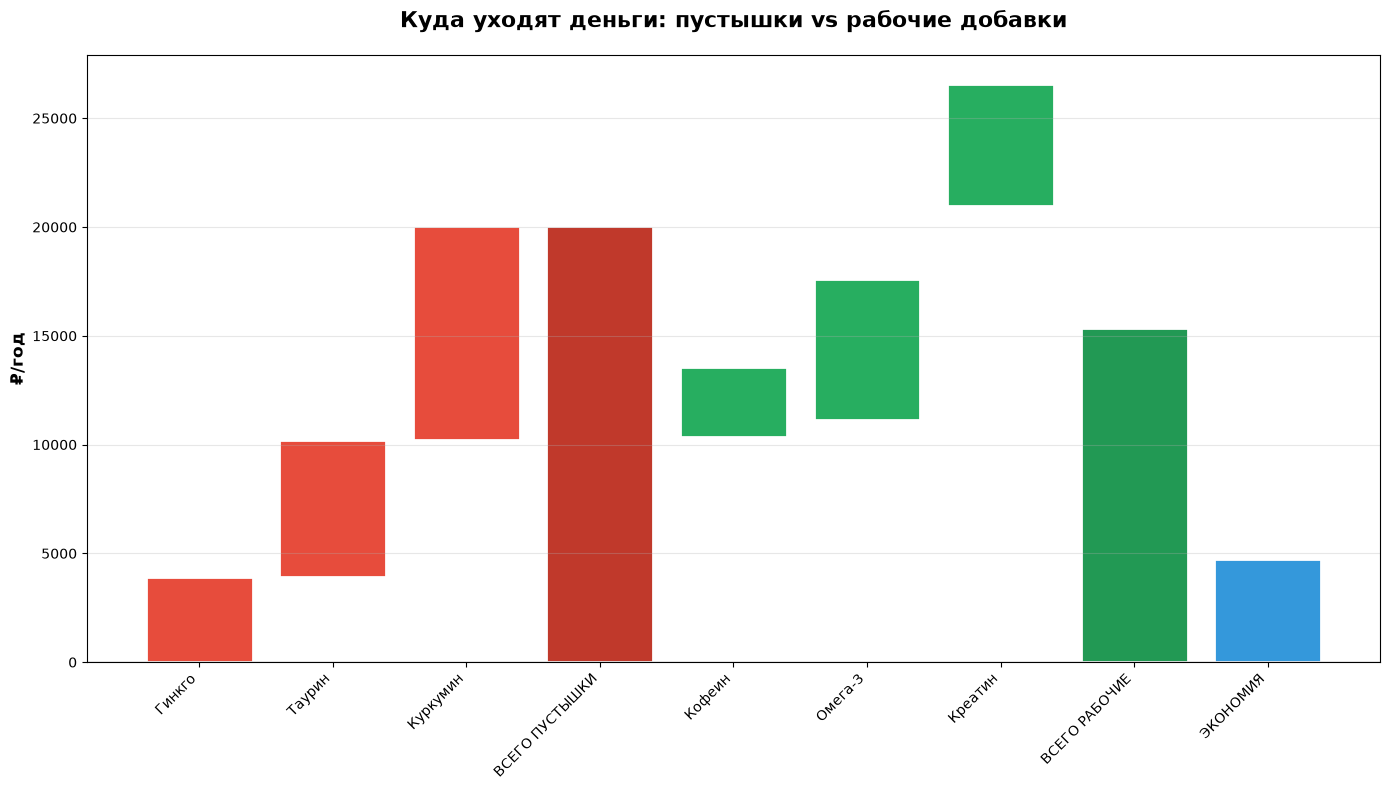

Сохранено: reports/waterfall_savings.png


In [26]:
import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path
import pandas as pd

PROCESSED = Path("..") / "data" / "processed"
df = pd.read_csv(PROCESSED / "evidence_scored.csv")

# Данные для waterfall
trash = df[df["вердикт"] == -1].sort_values("score", ascending=False).head(3)
gold = df[df["вердикт"] == 1].sort_values("score", ascending=False).head(3)

categories = list(trash["добавка"]) + ["ВСЕГО ПУСТЫШКИ"] + list(gold["добавка"]) + ["ВСЕГО РАБОЧИЕ", "ЭКОНОМИЯ"]
values = list(trash["цена_год"]) + [trash["цена_год"].sum()] + list(gold["цена_год"]) + [gold["цена_год"].sum(), trash["цена_год"].sum() - gold["цена_год"].sum()]

# Цвета: красный для пустышек, зелёный для рабочих, синий для итога
colors = ["#e74c3c"] * 3 + ["#c0392b"] + ["#27ae60"] * 3 + ["#229954", "#3498db"]

fig, ax = plt.subplots(figsize=(14, 8))

# Waterfall
bottom = 0
for i, (cat, val, col) in enumerate(zip(categories, values, colors)):
    if "ВСЕГО" in cat or "ЭКОНОМИЯ" in cat:
        ax.bar(cat, val, bottom=0, color=col, edgecolor="white", linewidth=2)
    else:
        ax.bar(cat, val, bottom=bottom if i < 4 else bottom - gold["цена_год"].sum() + gold["цена_год"].iloc[i-5] if i < 7 else 0,
               color=col, edgecolor="white", linewidth=2)
    if "ВСЕГО" not in cat and "ЭКОНОМИЯ" not in cat:
        bottom += val

ax.set_ylabel("₽/год", fontsize=12, fontweight="bold")
ax.set_title("Куда уходят деньги: пустышки vs рабочие добавки", fontsize=16, fontweight="bold", pad=20)
ax.axhline(y=0, color="black", linewidth=0.8)
ax.grid(axis="y", alpha=0.3)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("../reports/waterfall_savings.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: reports/waterfall_savings.png")

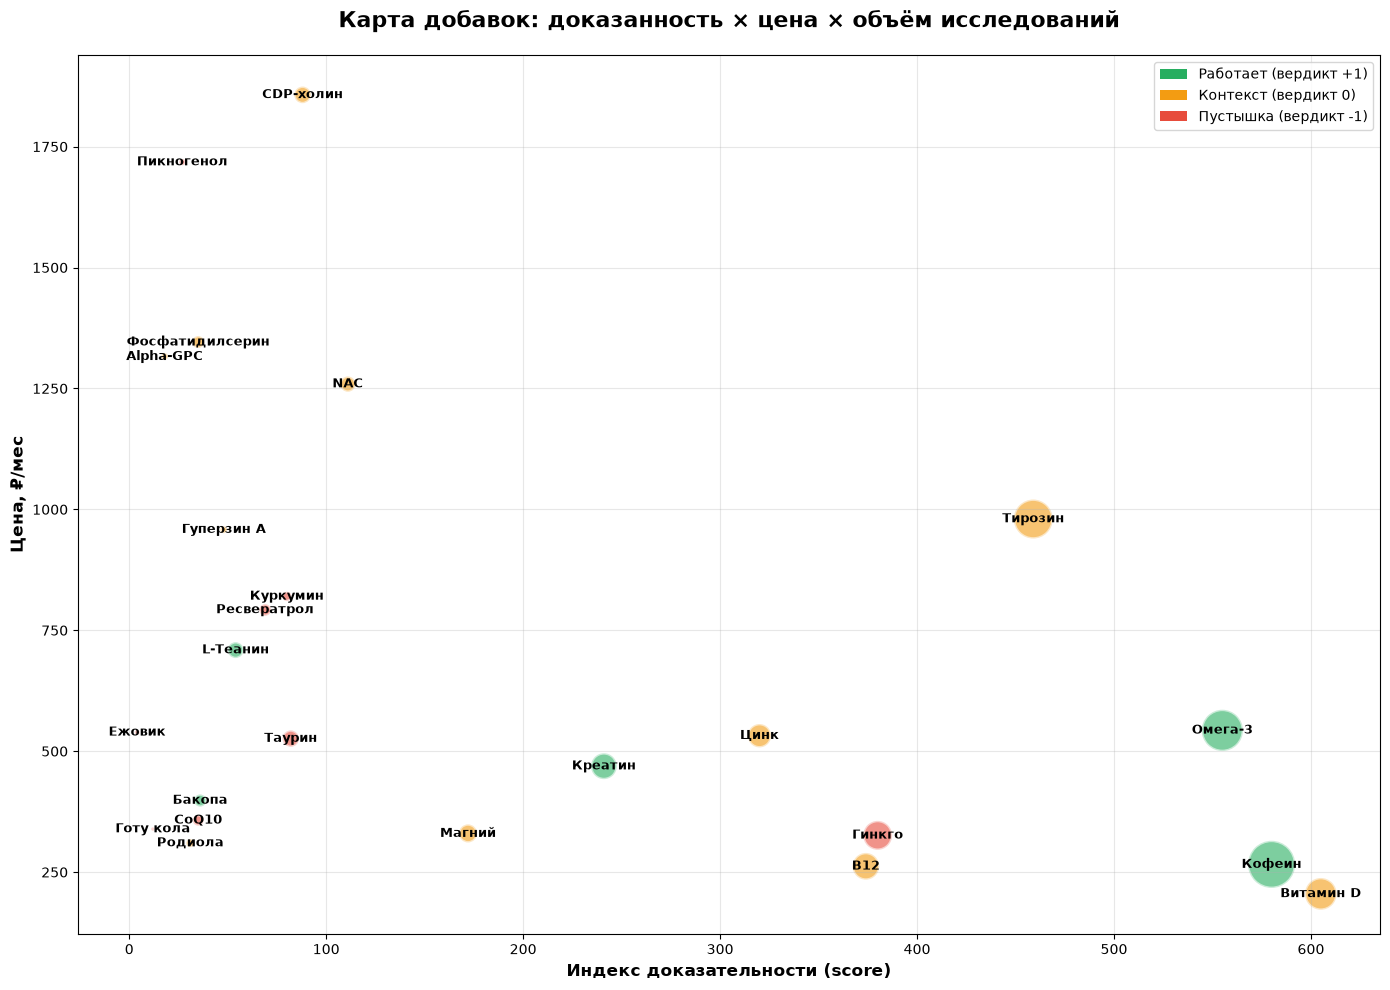

Сохранено: reports/bubble_chart.png


In [37]:
fig, ax = plt.subplots(figsize=(14, 10))

# Размер пузыря = количество RCT (больше = изученнее)
sizes = df["rct"] * 3  # масштабирование

# Цвет = вердикт
colors_map = {-1: "#e74c3c", 0: "#f39c12", 1: "#27ae60"}
colors = [colors_map[v] for v in df["вердикт"]]

scatter = ax.scatter(df["score"], df["цена_мес"], s=sizes, c=colors,
                     alpha=0.6, edgecolors="white", linewidth=2)

# Подписи добавок
for _, row in df.iterrows():
    ax.annotate(row["добавка"], (row["score"], row["цена_мес"]),
                fontsize=9, ha="center", va="center", fontweight="bold")

ax.set_xlabel("Индекс доказательности (score)", fontsize=12, fontweight="bold")
ax.set_ylabel("Цена, ₽/мес", fontsize=12, fontweight="bold")
ax.set_title("Карта добавок: доказанность × цена × объём исследований", fontsize=16, fontweight="bold", pad=20)

# Легенда
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="#27ae60", label="Работает (вердикт +1)"),
                   Patch(facecolor="#f39c12", label="Контекст (вердикт 0)"),
                   Patch(facecolor="#e74c3c", label="Пустышка (вердикт -1)")]
ax.legend(handles=legend_elements, loc="upper right", fontsize=10)

ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/bubble_chart.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: reports/bubble_chart.png")

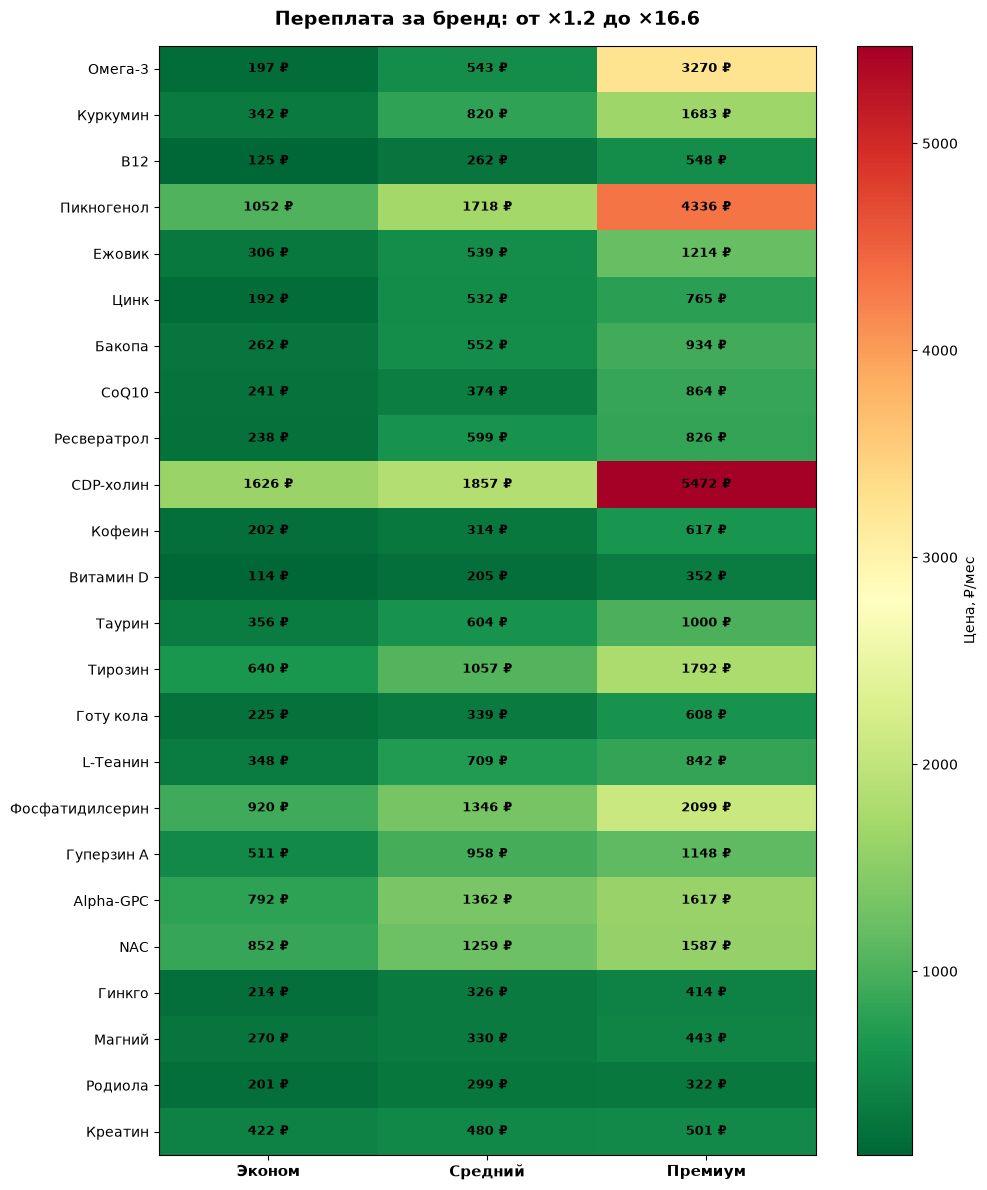

Сохранено: reports/heatmap_tiers.png


In [36]:
RAW = Path("..") / "data" / "raw"
wb = pd.read_excel(RAW / "prices_wb.xlsx")
wb["цена_мес"] = (wb["цена_упаковки"] / wb["единиц_в_упаковке"] * wb["норма_мес"]).round(0)
wb["категория"] = wb.groupby("добавка")["цена_мес"].transform(
    lambda s: pd.qcut(s.rank(method="first"), 3, labels=["эконом", "средний", "премиум"])
    if len(s) >= 3 else "средний")

tier = wb.pivot_table(index="добавка", columns="категория",
                      values="цена_мес", aggfunc="median").round(0)
tier["переплата_в_раз"] = (tier["премиум"] / tier["эконом"]).round(1)
tier = tier.sort_values("переплата_в_раз", ascending=False)

fig, ax = plt.subplots(figsize=(10, 12))
im = ax.imshow(tier[["эконом", "средний", "премиум"]].values, cmap="RdYlGn_r", aspect="auto")

ax.set_xticks(range(3))
ax.set_xticklabels(["Эконом", "Средний", "Премиум"], fontsize=11, fontweight="bold")
ax.set_yticks(range(len(tier)))
ax.set_yticklabels(tier.index, fontsize=10)

# Подписи значений
for i in range(len(tier)):
    for j in range(3):
        val = tier.iloc[i, j]
        if pd.notna(val):
            ax.text(j, i, f"{int(val)} ₽", ha="center", va="center",
                    fontsize=9, fontweight="bold", color="black")

ax.set_title(f"Переплата за бренд: от ×{tier['переплата_в_раз'].min():.1f} до ×{tier['переплата_в_раз'].max():.1f}",
             fontsize=14, fontweight="bold", pad=15)

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Цена, ₽/мес", fontsize=10)

plt.tight_layout()
plt.savefig("../reports/heatmap_tiers.png", dpi=150, bbox_inches="tight")
plt.show()
print("Сохранено: reports/heatmap_tiers.png")

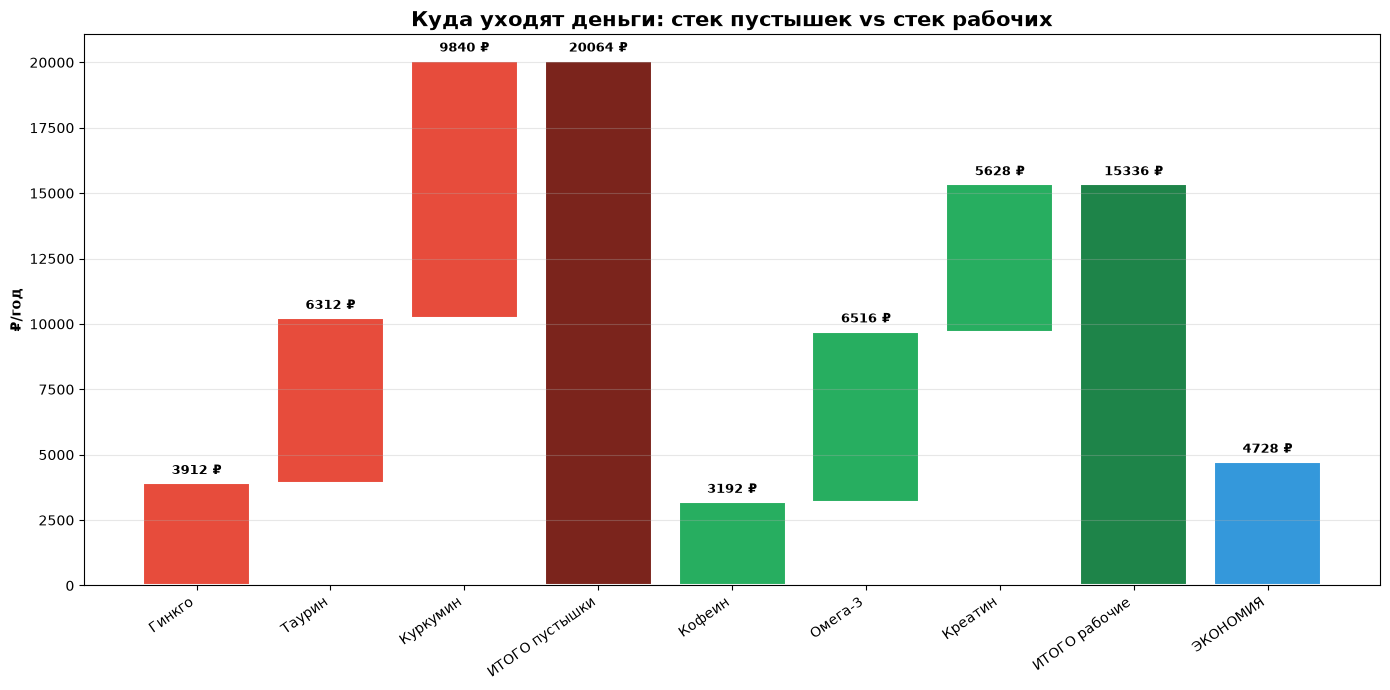

In [35]:
import matplotlib.pyplot as plt

labels, bottoms, heights, colors = [], [], [], []

cum = 0
for _, r in trash.iterrows():
    labels.append(r["добавка"]); heights.append(r["цена_год"])
    bottoms.append(cum); colors.append("#e74c3c"); cum += r["цена_год"]
labels.append("ИТОГО пустышки"); heights.append(cum); bottoms.append(0); colors.append("#7b241c")
trash_total = cum

cum = 0
for _, r in gold.iterrows():
    labels.append(r["добавка"]); heights.append(r["цена_год"])
    bottoms.append(cum); colors.append("#27ae60"); cum += r["цена_год"]
labels.append("ИТОГО рабочие"); heights.append(cum); bottoms.append(0); colors.append("#1e8449")
gold_total = cum

labels.append("ЭКОНОМИЯ"); heights.append(trash_total - gold_total)
bottoms.append(0); colors.append("#3498db")

fig, ax = plt.subplots(figsize=(14, 7))
ax.bar(labels, heights, bottom=bottoms, color=colors, edgecolor="white", linewidth=1.5)
for x, (h, b) in enumerate(zip(heights, bottoms)):
    ax.text(x, b + h + 350, f"{int(h)} ₽", ha="center", fontweight="bold", fontsize=9)
ax.set_ylabel("₽/год", fontweight="bold")
ax.set_title("Куда уходят деньги: стек пустышек vs стек рабочих", fontweight="bold", fontsize=15)
plt.xticks(rotation=35, ha="right")
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig("../reports/waterfall_savings.png", dpi=150, bbox_inches="tight")
plt.show()

In [31]:
wb[wb["добавка"] == "Ресвератрол"].sort_values("цена_мес")

,добавка,продукт,единиц_в_упаковке,цена_упаковки,норма_мес,источник,дата,цена_мес,категория
101,Ресвератрол,Florea Ресвератрол антиоксидант 60 капсул 200 мг,60,245,30,WB арт.504185662,2026-09-07,122.0,эконом
102,Ресвератрол,"MISTERLAB Ресвератрол 250 мг, 90 капсул",90,1062,30,WB арт.1290446902,2026-09-07,354.0,эконом
100,Ресвератрол,GLS pharmaceuticals Ресвератрол 50 мг GLS капс...,60,812,30,WB арт.822674964,2026-09-07,406.0,эконом
103,Ресвератрол,SOLGAR Ресвератрол 100 мг 60 капсул,60,1584,30,WB арт.1345201919,2026-09-07,792.0,средний
105,Ресвератрол,NOW Ресвератрол RESVERATROL 200 мг 60 капсул,60,1585,30,WB арт.330434553,2026-09-07,792.0,средний
106,Ресвератрол,TETRALAB Tetralab Ресвератрол 150 мг капсулы п...,60,1722,30,WB арт.822662344,2026-09-07,861.0,премиум
104,Ресвератрол,Алтай Ресвератрол природный антиоксидант 2 шт ...,2,2096,30,WB арт.502049224,2026-09-07,31440.0,премиум


In [34]:
wb[wb["добавка"] == "Родиола"].sort_values("цена_мес")

,добавка,продукт,единиц_в_упаковке,цена_упаковки,норма_мес,источник,дата,цена_мес,категория
64,Родиола,эколаб Родиола + витамин С 90 капсул,90,604,30,WB арт.455420502,2026-09-07,201.0,эконом
62,Родиола,Экстракт ВИС Родиолы розовой экстракт-ВИС капс...,30,299,30,WB арт.822680108,2026-09-07,299.0,эконом
61,Родиола,GLS pharmaceuticals Родиола розовая экстракт G...,60,645,30,WB арт.822665930,2026-09-07,322.0,средний
63,Родиола,– Родиолы экстракт жидкий для приема внутрь 30...,1,140,30,WB арт.822684736,2026-09-07,4200.0,премиум


In [39]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

from src import config, parsers, economics
print("NORM:", len(config.NORM), "| VERDICT:", len(config.VERDICT),
      "| WB_QUERY:", len(config.WB_QUERY))
print("Импорты src работают")

ImportError: cannot import name 'config' from 'src' (unknown location)

In [1]:
"""Сборщики данных: PubMed, OpenAlex, Wildberries."""
import re
import time
import requests
import pandas as pd

from .config import SUPPLEMENTS, COG, EN, NORM, WB_QUERY, MAILTO

EUTILS = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
OPENALEX = "https://api.openalex.org/works"
WB_SEARCH = "https://search.wb.ru/exactmatch/ru/common/v4/search"

# Чёрный список: товары для огорода/наборы, а не дозы
GARDEN = re.compile(r"семен|сажен|рассад|грунт|агрофирм|аэлит|цвето|растен|огород", re.I)

# ВАЖНО: токен «шт» убран — «1 шт/2 шт» это флаконы и наборы, не дозы
UNIT_RE = {
    "г":    re.compile(r"(\d+(?:[.,]\d+)?)\s*(?:грамм|граммов|г|g|гр)\b", re.I),
    "капс": re.compile(r"(\d+)\s*(?:капсул|капс|caps|capsules|таблеток|табл|таб)\b", re.I),
}


def pubmed_count(term: str) -> int:
    r = requests.get(EUTILS, params={"term": term, "retmode": "json",
                                     "email": MAILTO}, timeout=15)
    r.raise_for_status()
    time.sleep(0.35)
    return int(r.json()["esearchresult"]["count"])


def collect_pubmed() -> pd.DataFrame:
    """Полный сбор PubMed (использовать только для обновления данных)."""
    rows = []
    for name, q in SUPPLEMENTS.items():
        base = f"({q}) AND ({COG})"
        rows.append({
            "добавка": name,
            "всего_публикаций": pubmed_count(base),
            "rct": pubmed_count(f"{base} AND randomized controlled trial[pt]"),
            "мета_анализы": pubmed_count(f"{base} AND meta-analysis[pt]"),
        })
        print(f"{name}: собрано")
    return pd.DataFrame(rows)


def openalex_count(query: str) -> int:
    try:
        r = requests.get(OPENALEX, params={"search": query, "per-page": 1,
                                           "mailto": MAILTO}, timeout=8)
        r.raise_for_status()
        time.sleep(0.35)
        return int(r.json()["meta"]["count"])
    except Exception:
        return -1


def collect_openalex(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["name_en"] = df["добавка"].map(EN)
    df["openalex_works"] = [openalex_count(f"{en} cognition") for en in df["name_en"]]
    return df


def wb_search(query: str, n: int = 12) -> pd.DataFrame:
    r = requests.get(WB_SEARCH,
                     params={"appType": 1, "curr": "rub", "dest": -1257786,
                             "query": query, "resultset": "catalog",
                             "sort": "popular", "spp": 30},
                     timeout=15, headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    data = r.json()
    items = data.get("products", data.get("data", {}).get("products", []))[:n]
    rows = []
    for it in items:
        sizes = it.get("sizes", [])
        if not sizes or "price" not in sizes[0]:
            continue
        price_kop = sizes[0]["price"].get("product", sizes[0]["price"].get("basic", 0))
        rows.append({"артикул": it.get("id"), "бренд": it.get("brand", ""),
                     "название": it.get("name", ""), "цена_руб": round(price_kop / 100)})
    return pd.DataFrame(rows)


def parse_units(name: str, unit: str):
    m = UNIT_RE[unit].search(name)
    if not m:
        return None
    val = float(m.group(1).replace(",", "."))
    return int(val) if val.is_integer() else val


def collect_wb_prices() -> pd.DataFrame:
    """Сбор цен WB с фильтрами шума (наборы/огород отбрасываются)."""
    rows = []
    for sup, (q, unit) in WB_QUERY.items():
        try:
            offers = wb_search(q)
        except Exception as e:
            print(f"⚠️ {sup}: {type(e).__name__}")
            continue
        for _, o in offers.iterrows():
            if GARDEN.search(o["название"]):
                continue
            units = parse_units(o["название"], unit)
            if not units or units <= 0:
                continue
            rows.append({"добавка": sup, "продукт": f"{o['бренд']} {o['название']}",
                         "единиц_в_упаковке": units, "цена_упаковки": o["цена_руб"],
                         "норма_мес": NORM[sup], "источник": f"WB арт.{o['артикул']}",
                         "дата": time.strftime("%Y-%m-%d")})
        time.sleep(1.0)
    return pd.DataFrame(rows)

ImportError: attempted relative import with no known parent package

In [1]:
"""brain-25-evidence: единая конфигурация и словари проекта."""

MAILTO = "deadsno1613@gmail.com"   # polite-пул NCBI/OpenAlex

# Общий когнитивный фильтр для PubMed
COG = "cognition OR cognitive OR memory OR attention"

# Запросы PubMed (фикс-датасет собран 07.09.2026 и лежит в data/raw;
# эти строки нужны только для ПОВТОРНОГО сбора при обновлении)
SUPPLEMENTS = {
    "Креатин": "creatine",
    "Омега-3": '"omega-3" OR "fish oil"',
    "Витамин D": '"vitamin d" OR cholecalciferol',
    "B12": '"vitamin B12" OR cobalamin',
    "Магний": "magnesium",
    "Кофеин": "caffeine",
    "L-Теанин": "theanine OR \"l-theanine\"",
    "Бакопа": '"bacopa monnieri" OR bacopa',
    "Ежовик": '"hericium erinaceus" OR "lion\'s mane"',
    "Гинкго": '"ginkgo biloba" OR ginkgo',
    "Родиола": '"rhodiola rosea" OR rhodiola',
    "Ашваганда": 'ashwagandha OR "withania somnifera"',
    "Фосфатидилсерин": "phosphatidylserine",
    "Alpha-GPC": '"alpha-gpc" OR "choline alfoscerate"',
    "CDP-холин": 'citicoline OR "cdp-choline"',
    "Гуперзин А": 'huperzine OR "huperzine a"',
    "Куркумин": "curcumin",
    "Ресвератрол": "resveratrol",
    "NAC": '"n-acetylcysteine" OR acetylcysteine',
    "Цинк": "zinc",
    "Тирозин": 'tyrosine OR "l-tyrosine"',
    "Таурин": "taurine",
    "CoQ10": '"coenzyme q10" OR ubiquinone',
    "Пикногенол": 'pycnogenol OR "pine bark"',
    "Готу кола": '"centella asiatica" OR "gotu kola"',
}

# Английские имена для OpenAlex
EN = {"Креатин":"creatine","Омега-3":"omega-3 fatty acids","Витамин D":"vitamin D",
"B12":"vitamin B12","Магний":"magnesium","Кофеин":"caffeine","L-Теанин":"theanine",
"Бакопа":"bacopa monnieri","Ежовик":"hericium erinaceus","Гинкго":"ginkgo biloba",
"Родиола":"rhodiola rosea","Ашваганда":"ashwagandha","Фосфатидилсерин":"phosphatidylserine",
"Alpha-GPC":"alpha-gpc","CDP-холин":"citicoline","Гуперзин А":"huperzine",
"Куркумин":"curcumin","Ресвератрол":"resveratrol","NAC":"n-acetylcysteine",
"Цинк":"zinc","Тирозин":"tyrosine","Таурин":"taurine","CoQ10":"coenzyme q10",
"Пикногенол":"pycnogenol","Готу кола":"centella asiatica"}

# Суточная норма в единицах упаковки за 30 дней
NORM = {"Креатин":150,"Омега-3":60,"Витамин D":30,"B12":30,"Магний":30,
"Кофеин":30,"L-Теанин":30,"Бакопа":30,"Ежовик":60,"Гинкго":30,"Родиола":30,
"Ашваганда":30,"Фосфатидилсерин":30,"Alpha-GPC":30,"CDP-холин":30,
"Гуперзин А":30,"Куркумин":60,"Ресвератрол":30,"NAC":60,"Цинк":30,
"Тирозин":60,"Таурин":60,"CoQ10":30,"Пикногенол":30,"Готу кола":30}

# Вердикты мета-анализов (ручная разметка по Examine/Cochrane)
VERDICT = {"Креатин":1,"Омега-3":1,"Кофеин":1,"L-Теанин":1,"Бакопа":1,
"Ашваганда":1,"Витамин D":0,"B12":0,"Цинк":0,"Магний":0,"Родиола":0,
"CDP-холин":0,"Alpha-GPC":0,"Фосфатидилсерин":0,"Гуперзин А":0,"NAC":0,
"Тирозин":0,"Таурин":-1,"Ежовик":-1,"Пикногенол":-1,"Готу кола":-1,
"Куркумин":-1,"Ресвератрол":-1,"CoQ10":-1,"Гинкго":-1}

# Запросы Wildberries + тип единицы фасовки
WB_QUERY = {
    "Креатин": ("креатин моногидрат", "г"),
    "Омега-3": ("омега-3 капсулы", "капс"),
    "Витамин D": ("витамин d3 2000 ме", "капс"),
    "B12": ("витамин b12", "капс"),
    "Магний": ("магний b6", "капс"),
    "Кофеин": ("кофеин 200 мг", "капс"),
    "L-Теанин": ("l-теанин", "капс"),
    "Бакопа": ("бакопа моннье капсулы", "капс"),
    "Ежовик": ("ежовик гребенчатый", "капс"),
    "Гинкго": ("гинкго билоба", "капс"),
    "Родиола": ("родиола розовая", "капс"),
    "Ашваганда": ("ашваганда", "капс"),
    "Фосфатидилсерин": ("фосфатидилсерин", "капс"),
    "Alpha-GPC": ("alpha gpc", "капс"),
    "CDP-холин": ("цитиколин", "капс"),
    "Гуперзин А": ("гуперзин", "капс"),
    "Куркумин": ("куркумин", "капс"),
    "Ресвератрол": ("ресвератрол", "капс"),
    "NAC": ("nac ацетилцистеин", "капс"),
    "Цинк": ("цинк пиколинат", "капс"),
    "Тирозин": ("l-тирозин", "капс"),
    "Таурин": ("таурин", "капс"),
    "CoQ10": ("коэнзим q10", "капс"),
    "Пикногенол": ("пикногенол", "капс"),
    "Готу кола": ("готу кола", "капс"),
}

In [2]:
"""Сборщики данных: PubMed, OpenAlex, Wildberries."""
import re
import time
import requests
import pandas as pd

from .config import SUPPLEMENTS, COG, EN, NORM, WB_QUERY, MAILTO

EUTILS = "https://eutils.ncbi.nlm.nih.gov/entrez/eutils/esearch.fcgi"
OPENALEX = "https://api.openalex.org/works"
WB_SEARCH = "https://search.wb.ru/exactmatch/ru/common/v4/search"

# Чёрный список: товары для огорода/наборы, а не дозы
GARDEN = re.compile(r"семен|сажен|рассад|грунт|агрофирм|аэлит|цвето|растен|огород", re.I)

# ВАЖНО: токен «шт» убран — «1 шт/2 шт» это флаконы и наборы, не дозы
UNIT_RE = {
    "г":    re.compile(r"(\d+(?:[.,]\d+)?)\s*(?:грамм|граммов|г|g|гр)\b", re.I),
    "капс": re.compile(r"(\d+)\s*(?:капсул|капс|caps|capsules|таблеток|табл|таб)\b", re.I),
}


def pubmed_count(term: str) -> int:
    r = requests.get(EUTILS, params={"term": term, "retmode": "json",
                                     "email": MAILTO}, timeout=15)
    r.raise_for_status()
    time.sleep(0.35)
    return int(r.json()["esearchresult"]["count"])


def collect_pubmed() -> pd.DataFrame:
    """Полный сбор PubMed (использовать только для обновления данных)."""
    rows = []
    for name, q in SUPPLEMENTS.items():
        base = f"({q}) AND ({COG})"
        rows.append({
            "добавка": name,
            "всего_публикаций": pubmed_count(base),
            "rct": pubmed_count(f"{base} AND randomized controlled trial[pt]"),
            "мета_анализы": pubmed_count(f"{base} AND meta-analysis[pt]"),
        })
        print(f"{name}: собрано")
    return pd.DataFrame(rows)


def openalex_count(query: str) -> int:
    try:
        r = requests.get(OPENALEX, params={"search": query, "per-page": 1,
                                           "mailto": MAILTO}, timeout=8)
        r.raise_for_status()
        time.sleep(0.35)
        return int(r.json()["meta"]["count"])
    except Exception:
        return -1


def collect_openalex(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["name_en"] = df["добавка"].map(EN)
    df["openalex_works"] = [openalex_count(f"{en} cognition") for en in df["name_en"]]
    return df


def wb_search(query: str, n: int = 12) -> pd.DataFrame:
    r = requests.get(WB_SEARCH,
                     params={"appType": 1, "curr": "rub", "dest": -1257786,
                             "query": query, "resultset": "catalog",
                             "sort": "popular", "spp": 30},
                     timeout=15, headers={"User-Agent": "Mozilla/5.0"})
    r.raise_for_status()
    data = r.json()
    items = data.get("products", data.get("data", {}).get("products", []))[:n]
    rows = []
    for it in items:
        sizes = it.get("sizes", [])
        if not sizes or "price" not in sizes[0]:
            continue
        price_kop = sizes[0]["price"].get("product", sizes[0]["price"].get("basic", 0))
        rows.append({"артикул": it.get("id"), "бренд": it.get("brand", ""),
                     "название": it.get("name", ""), "цена_руб": round(price_kop / 100)})
    return pd.DataFrame(rows)


def parse_units(name: str, unit: str):
    m = UNIT_RE[unit].search(name)
    if not m:
        return None
    val = float(m.group(1).replace(",", "."))
    return int(val) if val.is_integer() else val


def collect_wb_prices() -> pd.DataFrame:
    """Сбор цен WB с фильтрами шума (наборы/огород отбрасываются)."""
    rows = []
    for sup, (q, unit) in WB_QUERY.items():
        try:
            offers = wb_search(q)
        except Exception as e:
            print(f"⚠️ {sup}: {type(e).__name__}")
            continue
        for _, o in offers.iterrows():
            if GARDEN.search(o["название"]):
                continue
            units = parse_units(o["название"], unit)
            if not units or units <= 0:
                continue
            rows.append({"добавка": sup, "продукт": f"{o['бренд']} {o['название']}",
                         "единиц_в_упаковке": units, "цена_упаковки": o["цена_руб"],
                         "норма_мес": NORM[sup], "источник": f"WB арт.{o['артикул']}",
                         "дата": time.strftime("%Y-%m-%d")})
        time.sleep(1.0)
    return pd.DataFrame(rows)

ImportError: attempted relative import with no known parent package

In [1]:
import sys
from pathlib import Path
sys.path.append(str(Path("..").resolve()))

from src import config, parsers, economics
print("NORM:", len(config.NORM), "| VERDICT:", len(config.VERDICT),
      "| WB_QUERY:", len(config.WB_QUERY))
print("Импорты src работают ✅")

NORM: 25 | VERDICT: 25 | WB_QUERY: 25
Импорты src работают ✅


In [2]:
import pandas as pd
from pathlib import Path

RAW = Path("..") / "data" / "raw"
PROC = Path("..") / "data" / "processed"

wb = pd.read_excel(RAW / "prices_wb.xlsx")
df = pd.read_csv(PROC / "evidence_scored.csv")

print("prices_wb.xlsx:", wb.shape, "| добавок:", wb["добавка"].nunique())
print("evidence_scored.csv:", df.shape)
print("колонки:", list(df.columns))

prices_wb.xlsx: (166, 9) | добавок: 24
evidence_scored.csv: (25, 11)
колонки: ['добавка', 'всего_публикаций', 'rct', 'мета_анализы', 'score', 'name_en', 'openalex_works', 'rct_share', 'вердикт', 'цена_мес', 'цена_год']
